# Combined Chromatin Deconvolution Run
March 7, 2024

Trial combined chromatin deconvolution model run

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import CombinedChromatinModel

config1 = load_yl_rg1_vst_config(1)
config2 = load_yl_rg1_vst_config(2)
combined_model = CombinedChromatinModel(config1, config2)


In [36]:

def deconvolve_combined(gene_name, outdir):
    combined_model.load_combined_mnase_gene(gene_name)
    # Deconvolve
    combined_model.deconvolve(verbose=True)
    fig = combined_model.plot_raw_prediction(1, vmax=50)
    fig = combined_model.plot_raw_prediction(2, vmax=50)

    # Deconvolve the combined gene expression model
    from src.config import load_combined_yl_alpha_vst_gene_expression_config
    from src.model import Model

    combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
    ge_model = Model(combined_ge_config, gene_name)
    ge_model.deconvolve_find_optimal_gamma()

    fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=50, ge_model=ge_model)
    plt.savefig(f"{outdir}/{gene_name}_deconvolution.png", dpi=150)
    plt.close(fig)
    
    fig = combined_model.plot_raw_prediction(1, vmax=50)
    plt.savefig(f"{outdir}/{gene_name}_rep1.png", dpi=150)
    plt.close(fig)
    
    fig = combined_model.plot_raw_prediction(2, vmax=50)
    plt.savefig(f"{outdir}/{gene_name}_rep2.png", dpi=150)
    plt.close(fig)
    
    return combined_model, combined_ge_config


Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Deconvolving combined model with gamma=0.006, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 200)
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 07 06:05:41 PM: Your problem has 45400 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 07 06:05:41 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 06:05:41 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 06:05:41 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
----------------------

(CVXPY) Mar 07 06:05:56 PM: 24  1.2e-04  1.2e-04  9.7e-06  4.91e-01   1.829562902e+03   1.829562218e+03   1.2e-04  6.83  
(CVXPY) Mar 07 06:05:57 PM: 25  9.0e-05  9.0e-05  7.0e-06  5.27e-01   1.801924072e+03   1.801923425e+03   9.0e-05  6.92  
(CVXPY) Mar 07 06:05:57 PM: 26  6.7e-05  6.7e-05  4.8e-06  5.65e-01   1.773782052e+03   1.773781457e+03   6.7e-05  7.01  
(CVXPY) Mar 07 06:05:57 PM: 27  4.9e-05  4.9e-05  3.2e-06  5.99e-01   1.744996895e+03   1.744996367e+03   4.9e-05  7.11  
(CVXPY) Mar 07 06:05:57 PM: Optimizer terminated. Time: 7.24    
(CVXPY) Mar 07 06:05:57 PM: 
(CVXPY) Mar 07 06:05:57 PM: 
(CVXPY) Mar 07 06:05:57 PM: Interior-point solution summary
(CVXPY) Mar 07 06:05:57 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Mar 07 06:05:57 PM:   Solution status : OPTIMAL
(CVXPY) Mar 07 06:05:57 PM:   Primal.  obj: 1.7449968952e+03    nrm: 3e+04    Viol.  con: 3e-04    var: 4e+01    cones: 0e+00  
(CVXPY) Mar 07 06:05:57 PM:   Dual.    obj: 1.7449963673e+03    nrm: 2e+

(CVXPY) Mar 07 06:06:26 PM: 10  5.1e-02  5.1e-02  1.1e-02  1.39e+00   2.361060689e+03   2.361078516e+03   5.1e-02  4.95  
(CVXPY) Mar 07 06:06:26 PM: 11  2.8e-02  2.8e-02  5.3e-03  1.18e+00   2.361246875e+03   2.361256595e+03   2.8e-02  5.07  
(CVXPY) Mar 07 06:06:26 PM: 12  2.3e-02  2.3e-02  4.2e-03  6.31e-01   2.355113847e+03   2.355122321e+03   2.3e-02  5.17  
(CVXPY) Mar 07 06:06:27 PM: 13  1.6e-02  1.6e-02  2.9e-03  4.87e-01   2.342884154e+03   2.342890719e+03   1.6e-02  5.26  
(CVXPY) Mar 07 06:06:27 PM: 14  1.1e-02  1.1e-02  1.8e-03  3.55e-01   2.328360396e+03   2.328365274e+03   1.1e-02  5.35  
(CVXPY) Mar 07 06:06:27 PM: 15  8.2e-03  8.2e-03  1.3e-03  3.10e-01   2.319049296e+03   2.319053405e+03   8.2e-03  5.45  
(CVXPY) Mar 07 06:06:27 PM: 16  6.8e-03  6.8e-03  1.0e-03  3.05e-01   2.311758864e+03   2.311762478e+03   6.8e-03  5.55  
(CVXPY) Mar 07 06:06:27 PM: 17  4.8e-03  4.8e-03  6.8e-04  3.02e-01   2.297836445e+03   2.297839263e+03   4.8e-03  5.64  
(CVXPY) Mar 07 06:06:27 

(CVXPY) Mar 07 06:07:03 PM: Optimizer  - Constraints            : 51402           
(CVXPY) Mar 07 06:07:03 PM: Optimizer  - Cones                  : 2               
(CVXPY) Mar 07 06:07:03 PM: Optimizer  - Scalar variables       : 171204            conic                  : 6204            
(CVXPY) Mar 07 06:07:03 PM: Optimizer  - Semi-definite variables: 0                 scalarized             : 0               
(CVXPY) Mar 07 06:07:03 PM: Factor     - setup time             : 1.13            
(CVXPY) Mar 07 06:07:03 PM: Factor     - dense det. time        : 0.00              GP order time          : 0.00            
(CVXPY) Mar 07 06:07:03 PM: Factor     - nonzeros before factor : 5.96e+06          after factor           : 5.96e+06        
(CVXPY) Mar 07 06:07:03 PM: Factor     - dense dim.             : 2                 flops                  : 1.76e+09        
(CVXPY) Mar 07 06:07:03 PM: ITE PFEAS    DFEAS    GFEAS    PRSTATUS   POBJ              DOBJ              MU       TIME  



(CVXPY) Mar 07 06:07:34 PM: Problem
(CVXPY) Mar 07 06:07:34 PM:   Name                   :                 
(CVXPY) Mar 07 06:07:34 PM:   Objective sense        : maximize        
(CVXPY) Mar 07 06:07:34 PM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Mar 07 06:07:34 PM:   Constraints            : 199002          
(CVXPY) Mar 07 06:07:34 PM:   Affine conic cons.     : 0               
(CVXPY) Mar 07 06:07:34 PM:   Disjunctive cons.      : 0               
(CVXPY) Mar 07 06:07:34 PM:   Cones                  : 2               
(CVXPY) Mar 07 06:07:34 PM:   Scalar variables       : 358804          
(CVXPY) Mar 07 06:07:34 PM:   Matrix variables       : 0               
(CVXPY) Mar 07 06:07:34 PM:   Integer variables      : 0               
(CVXPY) Mar 07 06:07:34 PM: 
(CVXPY) Mar 07 06:07:34 PM: Optimizer started.
(CVXPY) Mar 07 06:07:34 PM: Presolve started.
(CVXPY) Mar 07 06:07:34 PM: Linear dependency checker started.
(CVXPY) Mar 07 06:07:34 PM: Linear depe

(CVXPY) Mar 07 06:07:58 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 06:07:58 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 06:07:58 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 07 06:07:58 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 07 06:07:58 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Mar 07 06:07:58 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 07 06:07:58 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 07 06:07:58 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 07 06:08:01 PM: Applying reduction MOSEK
(CVXPY) Mar 07 06:08:03 PM: Finished problem co

(CVXPY) Mar 07 06:08:13 PM: 
(CVXPY) Mar 07 06:08:13 PM: Interior-point solution summary
(CVXPY) Mar 07 06:08:13 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Mar 07 06:08:13 PM:   Solution status : OPTIMAL
(CVXPY) Mar 07 06:08:13 PM:   Primal.  obj: 2.0880698609e+03    nrm: 2e+04    Viol.  con: 3e-04    var: 4e+01    cones: 0e+00  
(CVXPY) Mar 07 06:08:13 PM:   Dual.    obj: 2.0880695021e+03    nrm: 2e+03    Viol.  con: 0e+00    var: 3e-04    cones: 0e+00  
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
(CVXPY) Mar 07 06:08:13 PM: Problem status: optimal
(CVXPY) Mar 07 06:08:13 PM: Optimal value: 2.036e+03
(CVXPY) Mar 07 06:08:13 PM: Compilation took 5.011e+00 seconds
(CVXPY) Mar 07 06:08:13 PM: Solver (including time spent in interface) took 1.023e+01 seconds
Deconvolved in : 00:00:1

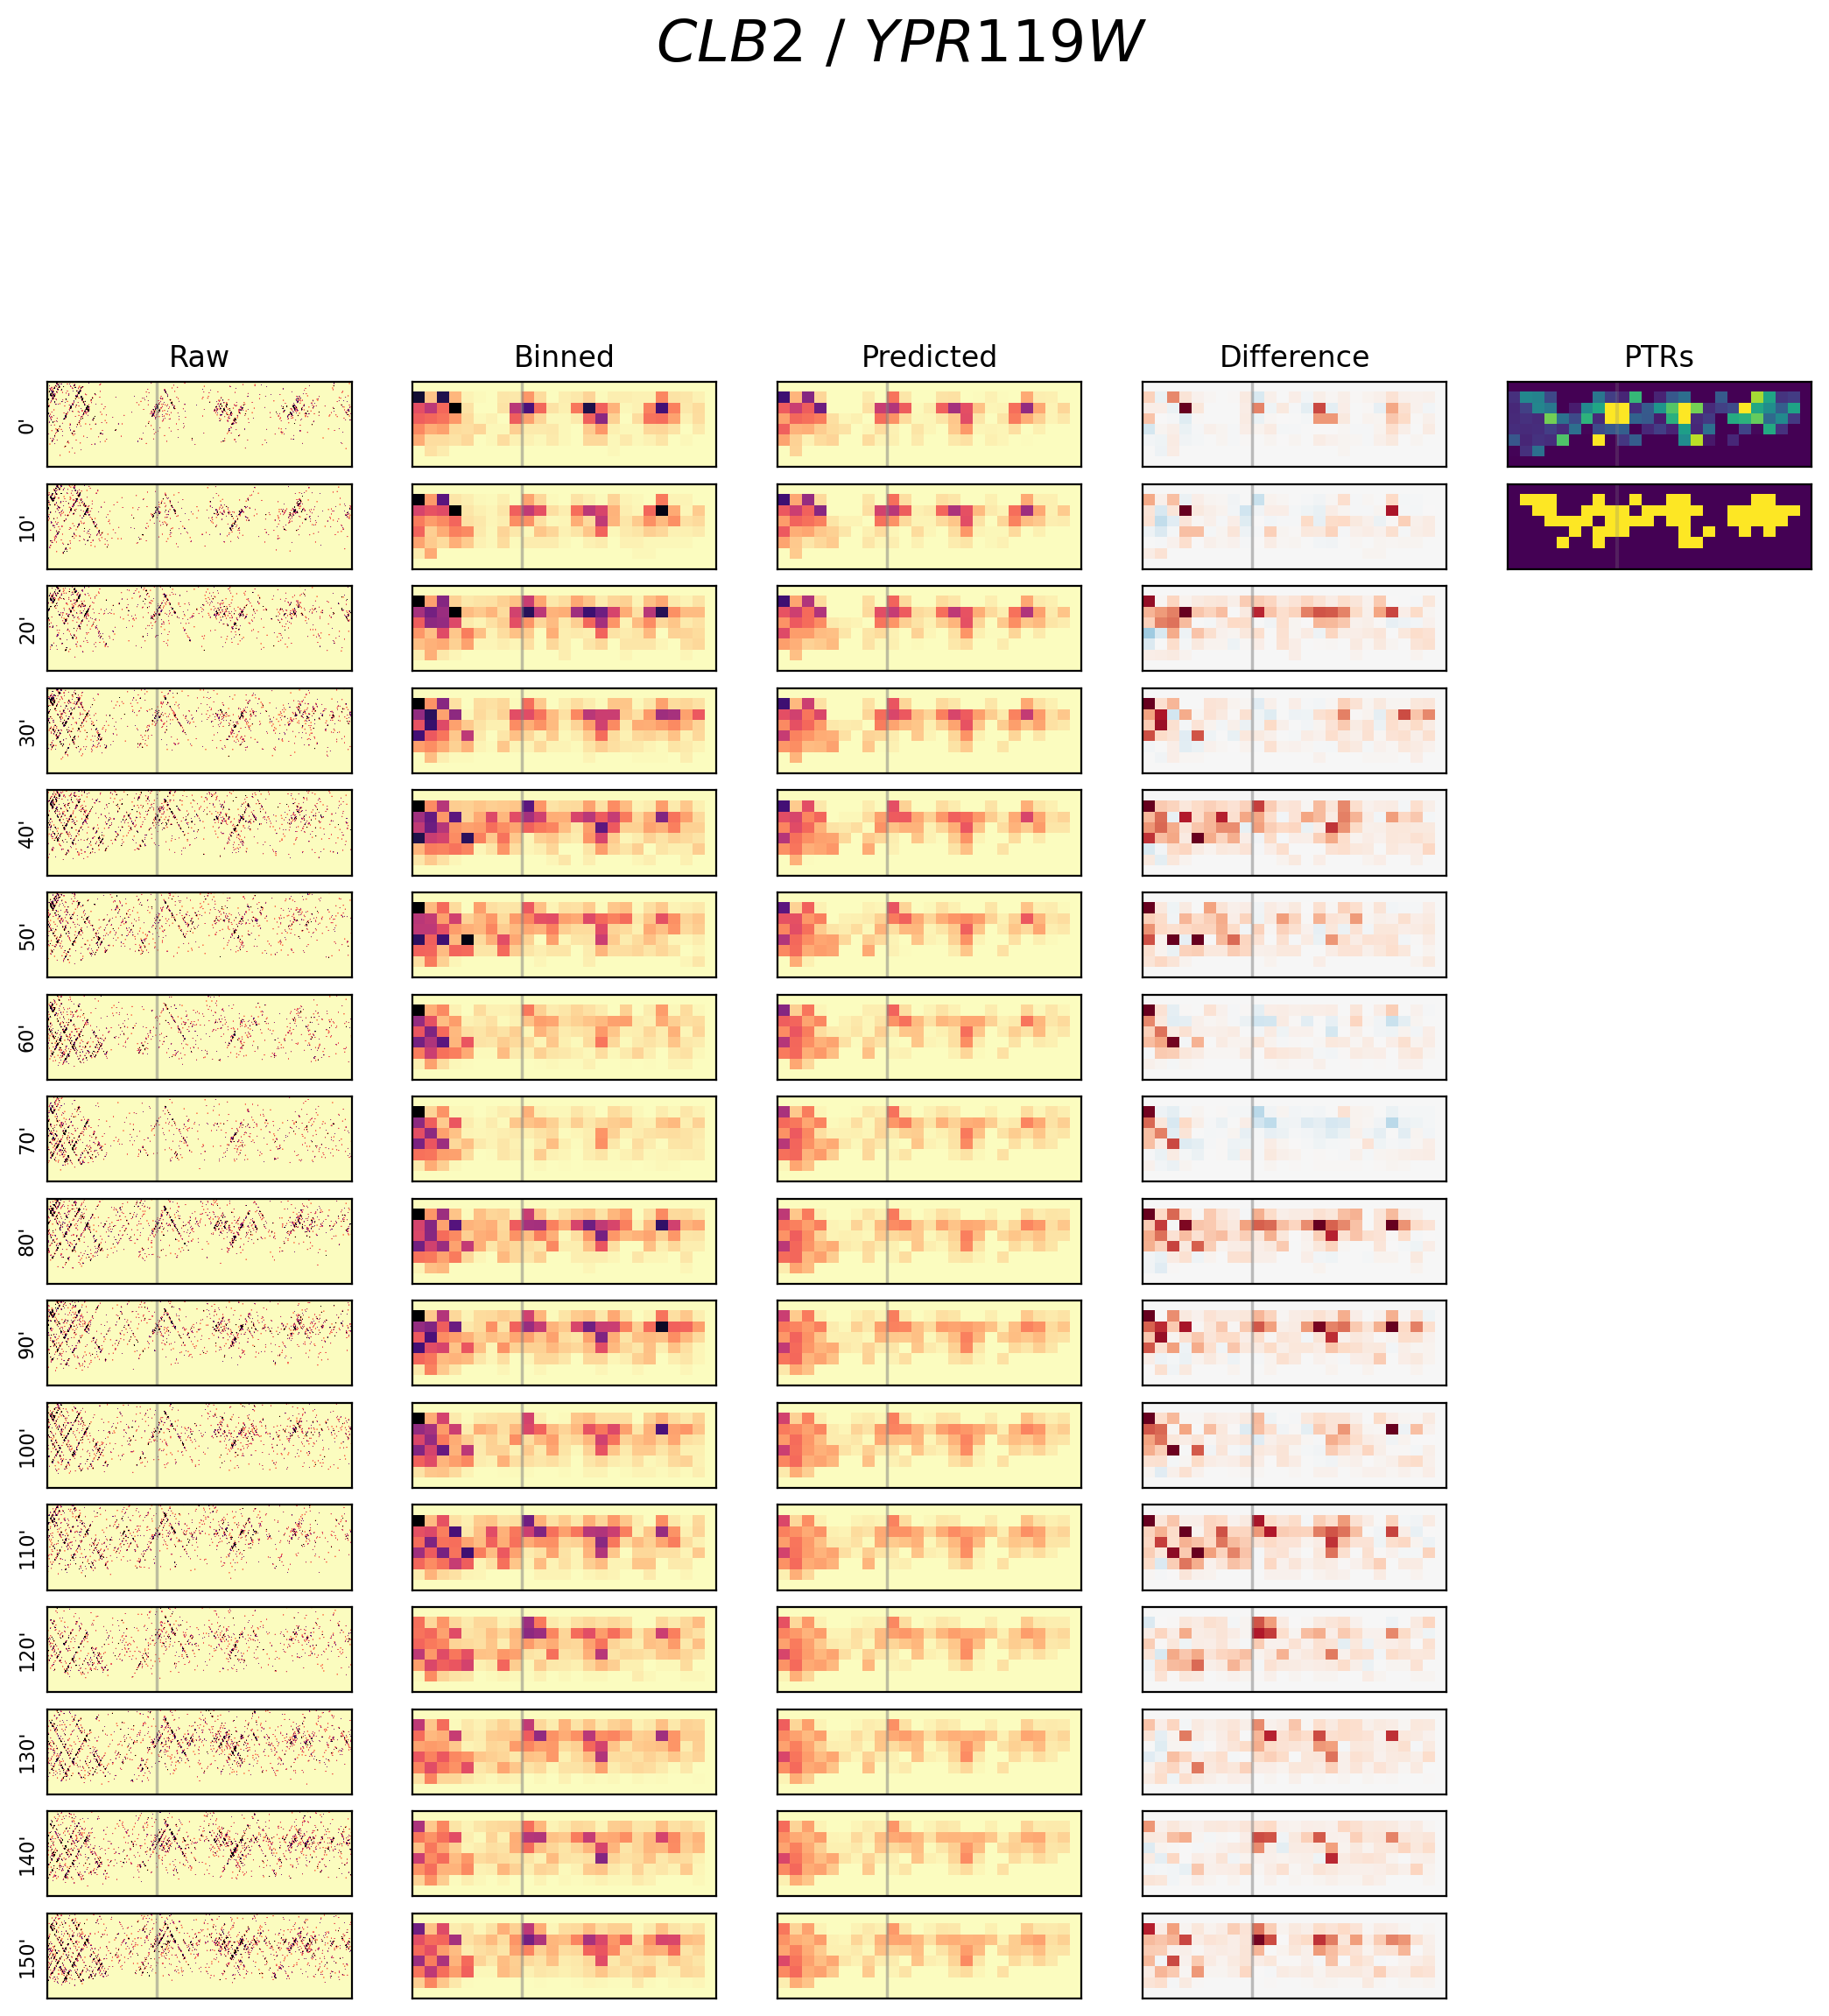

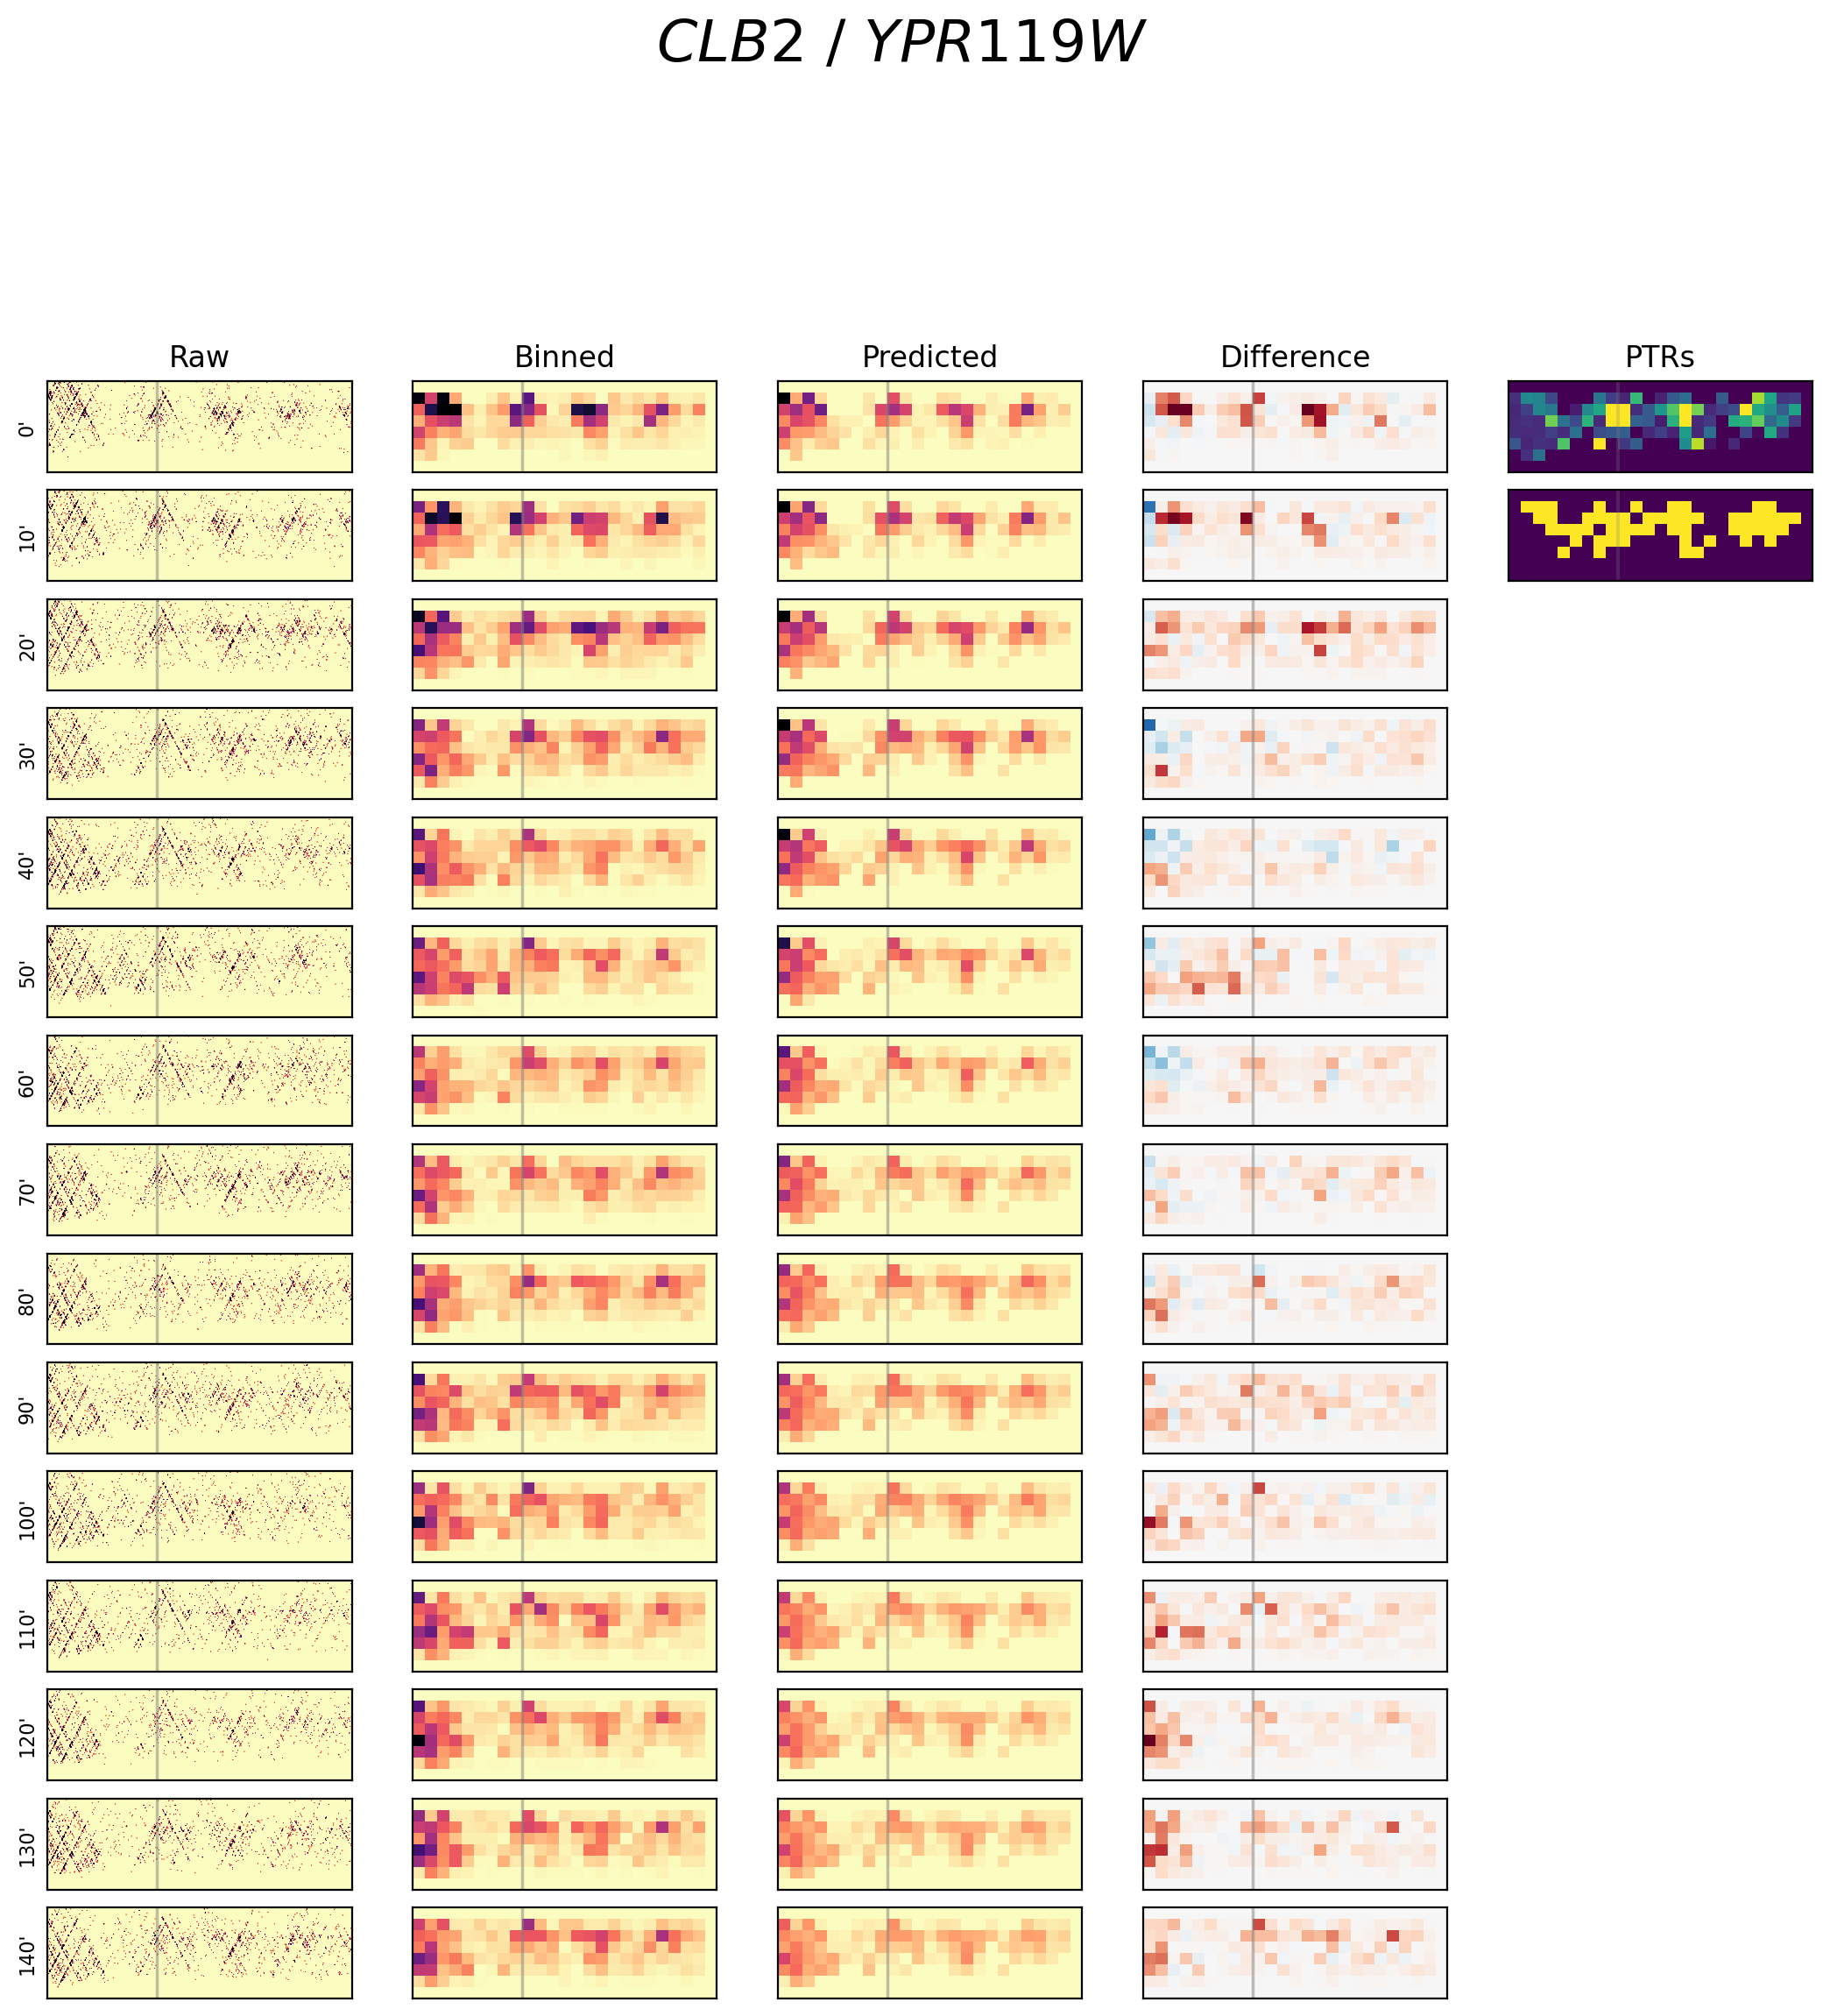

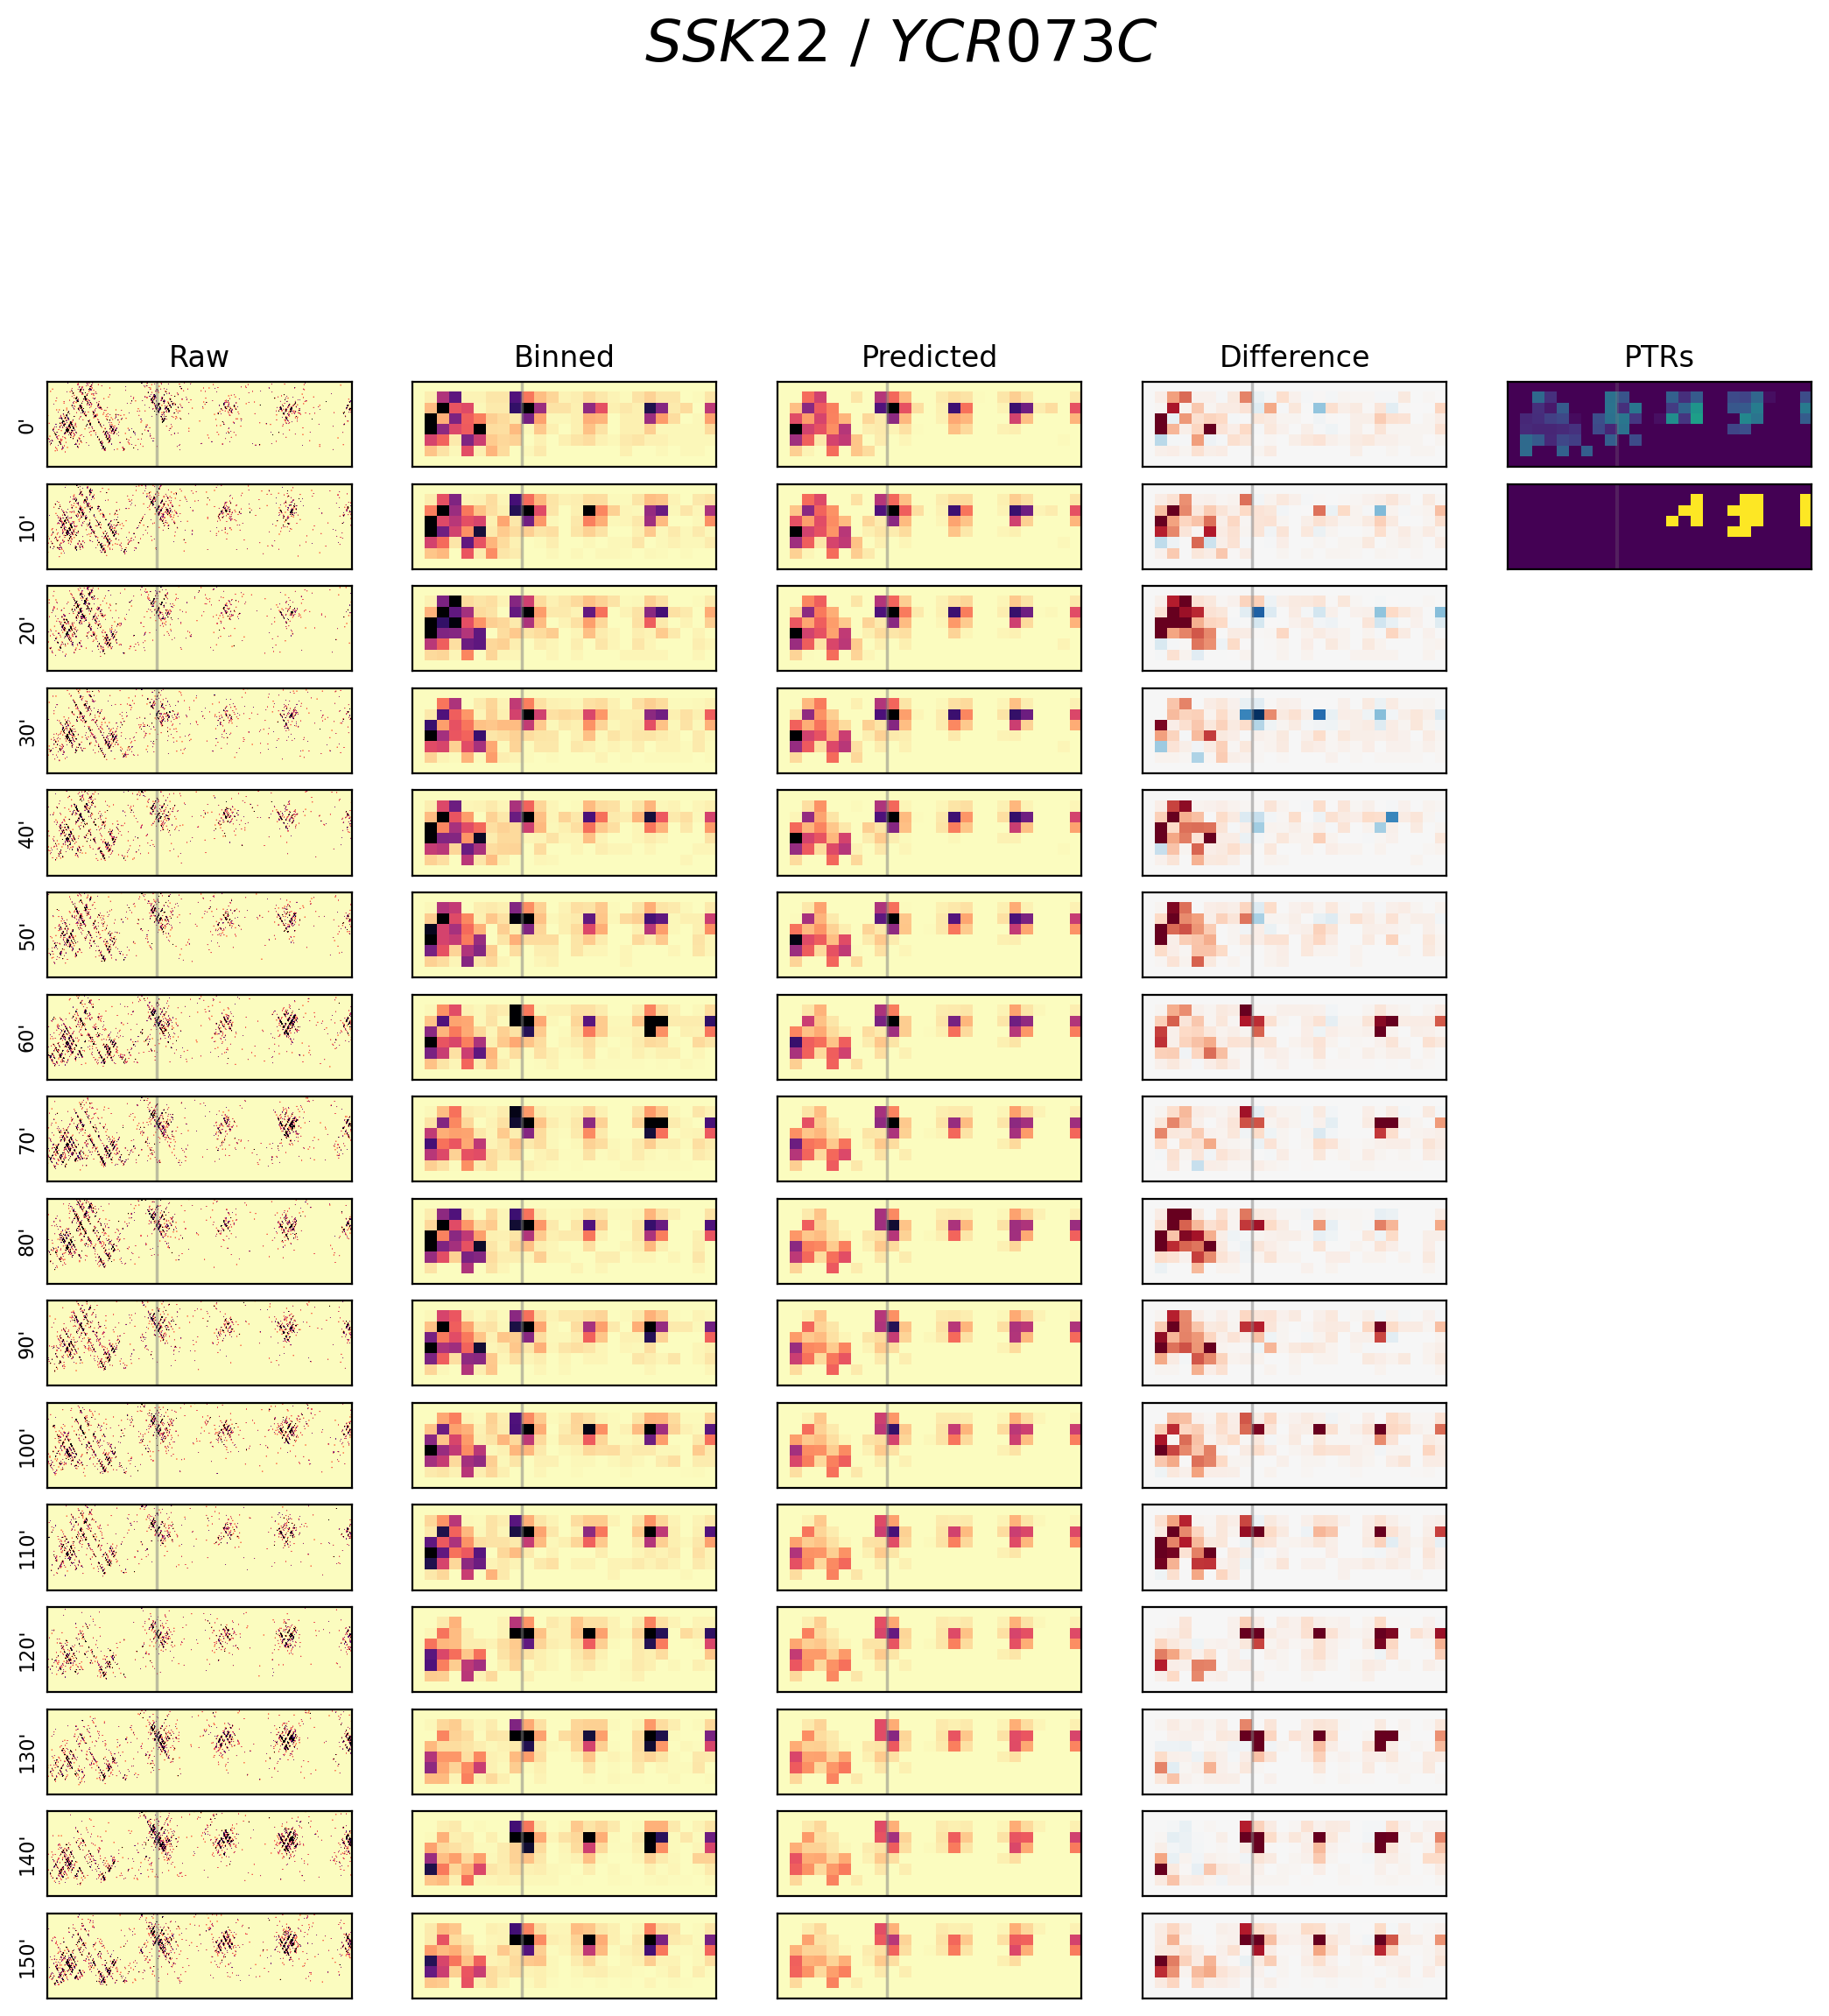

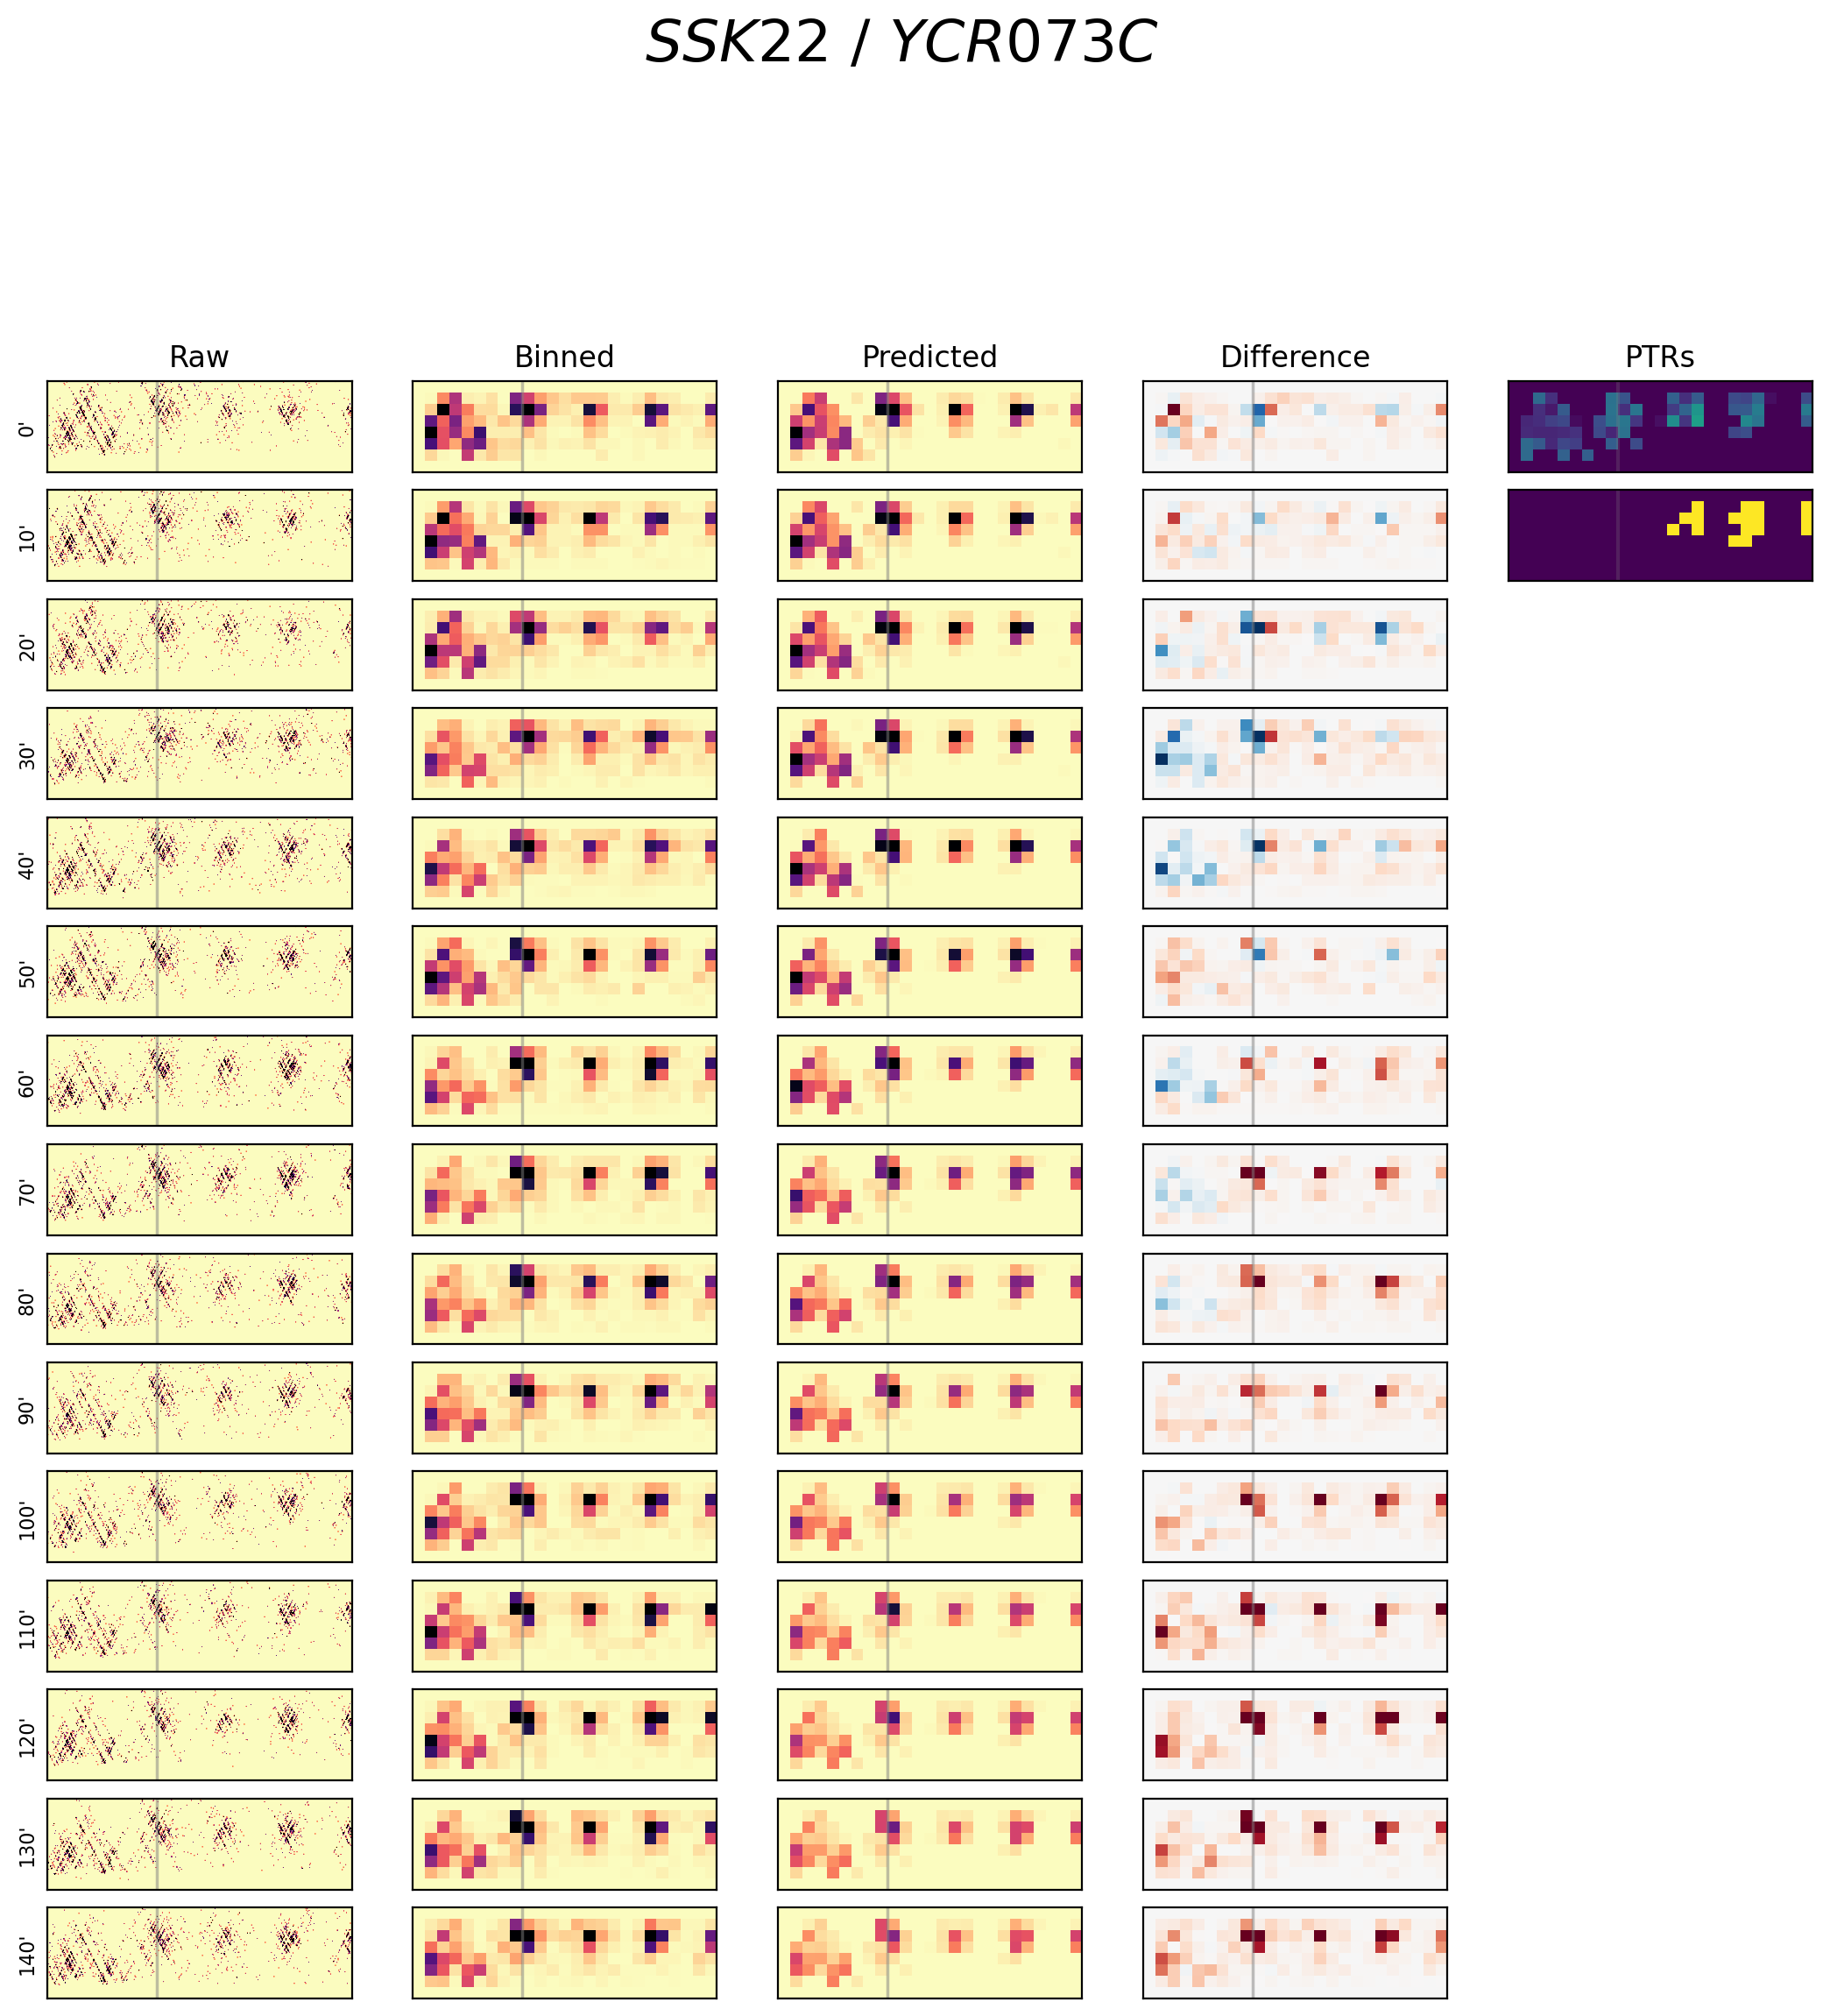

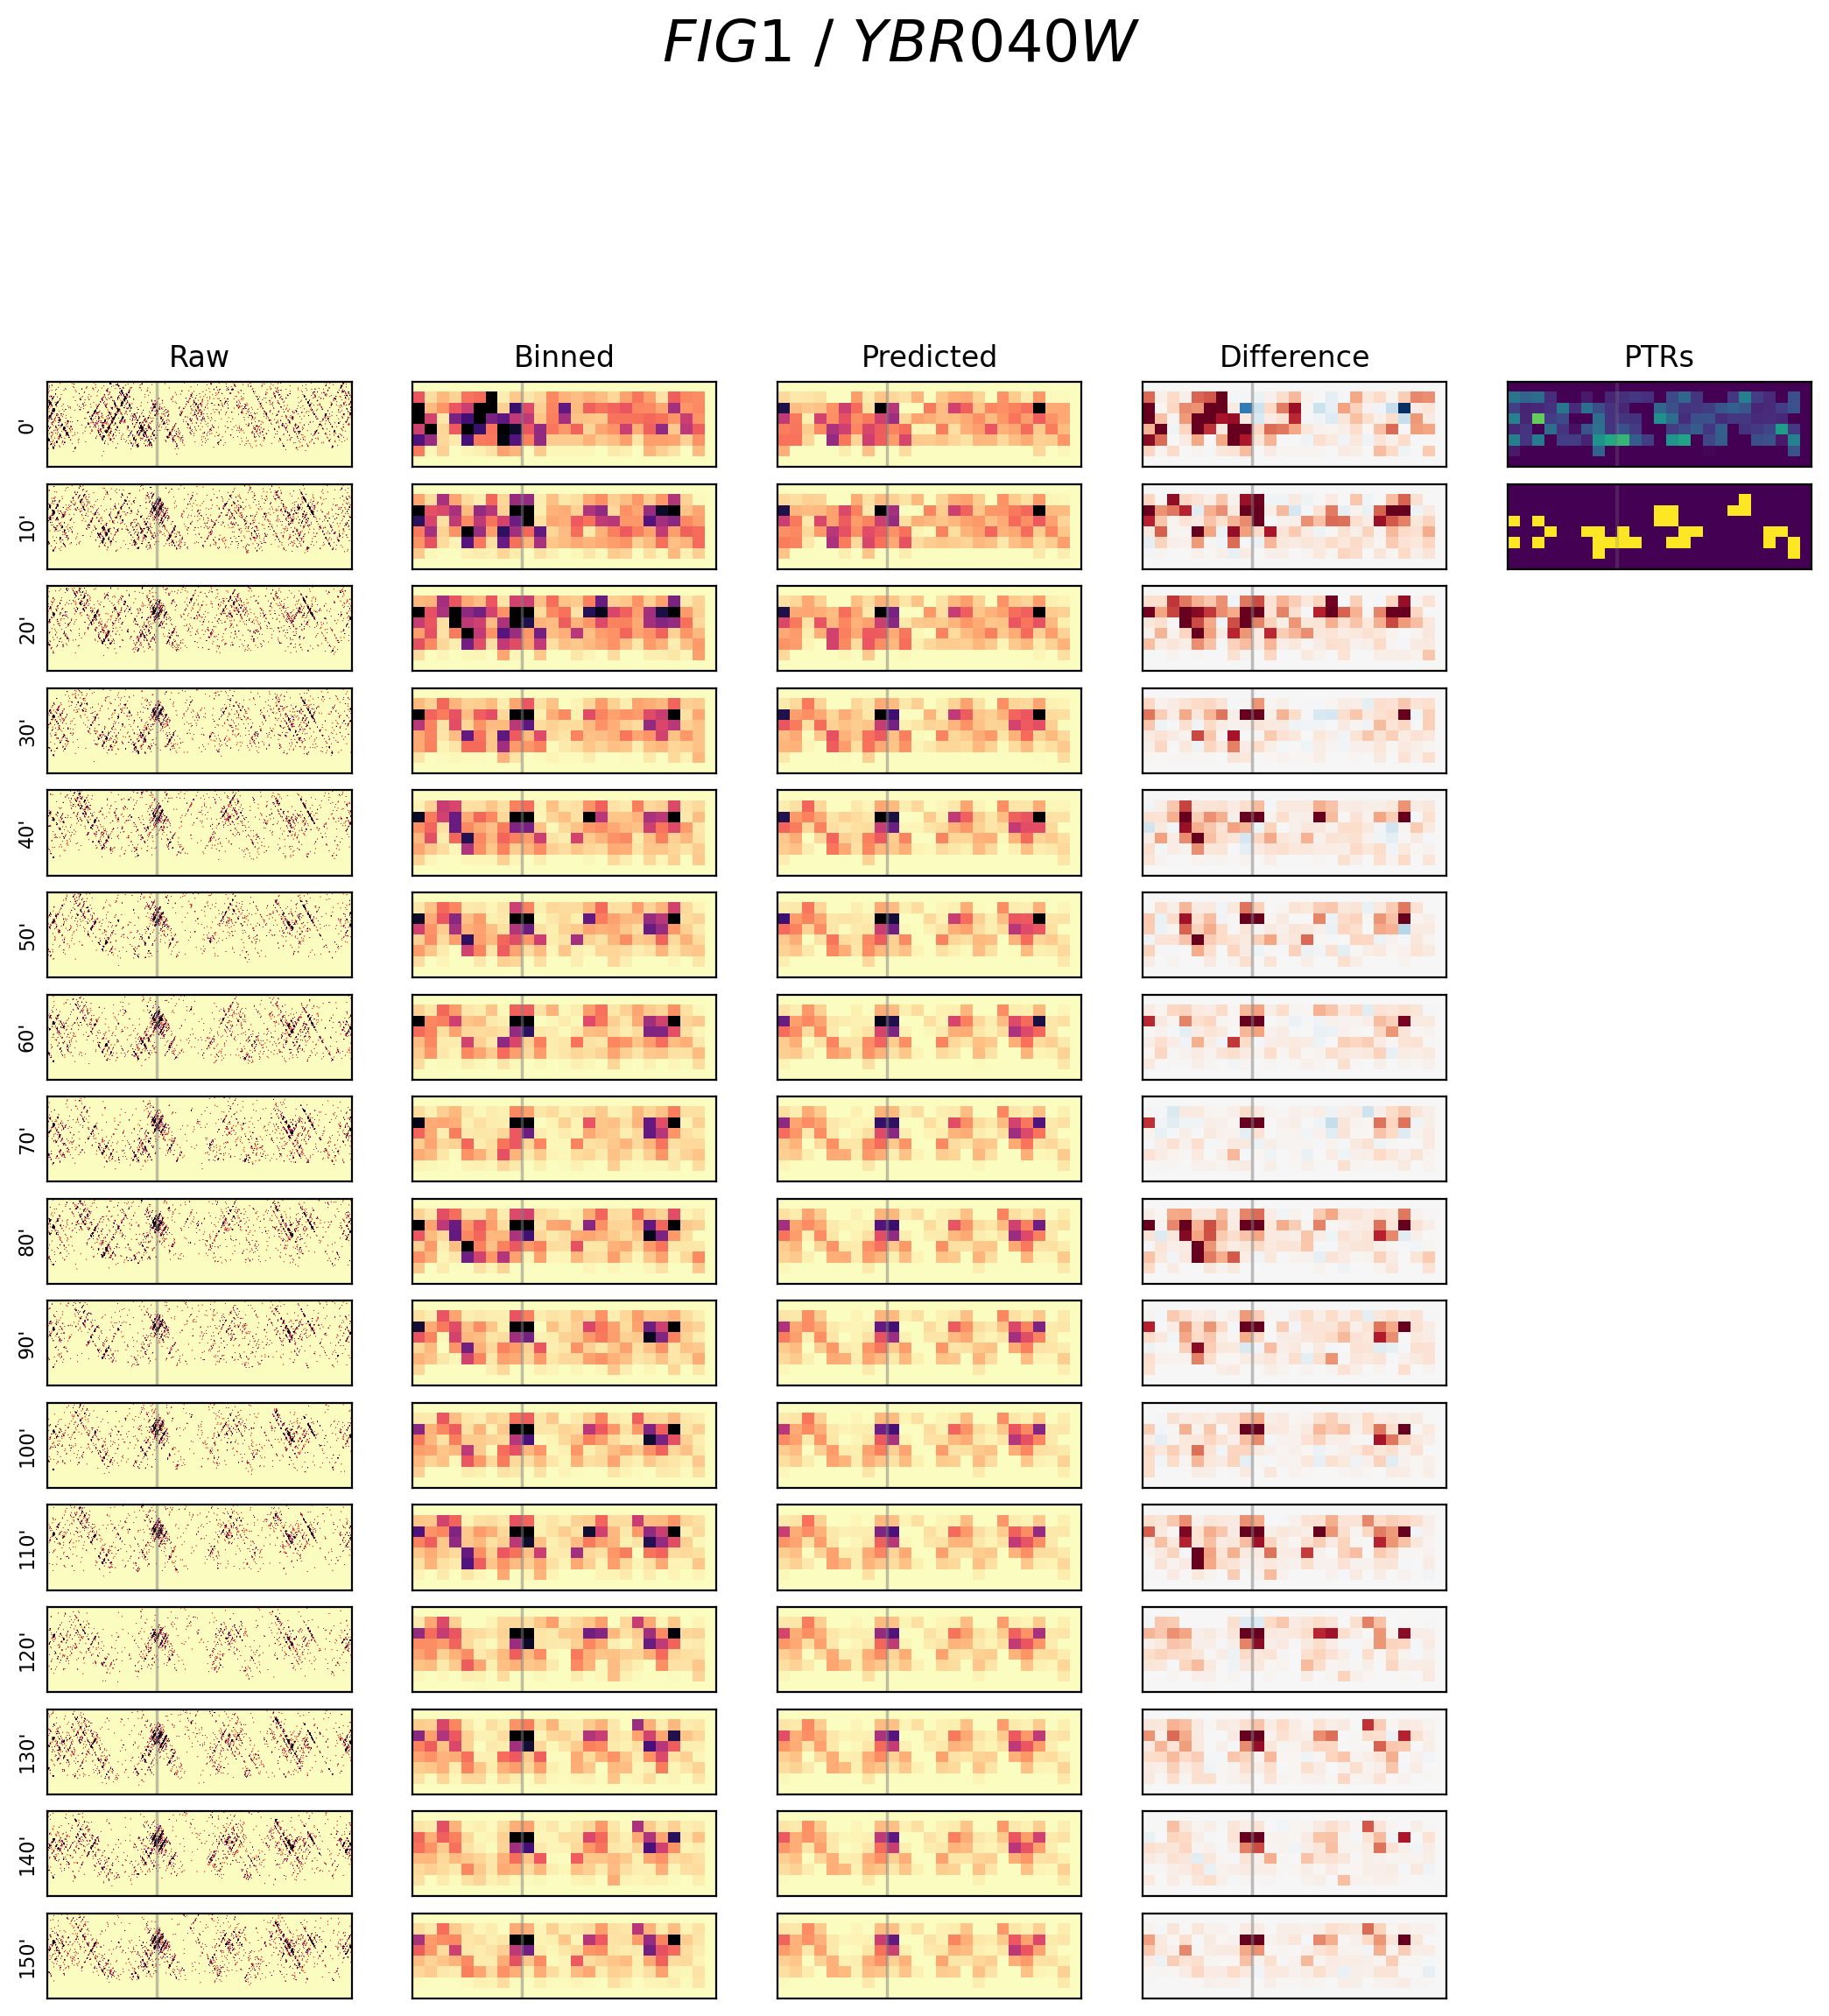

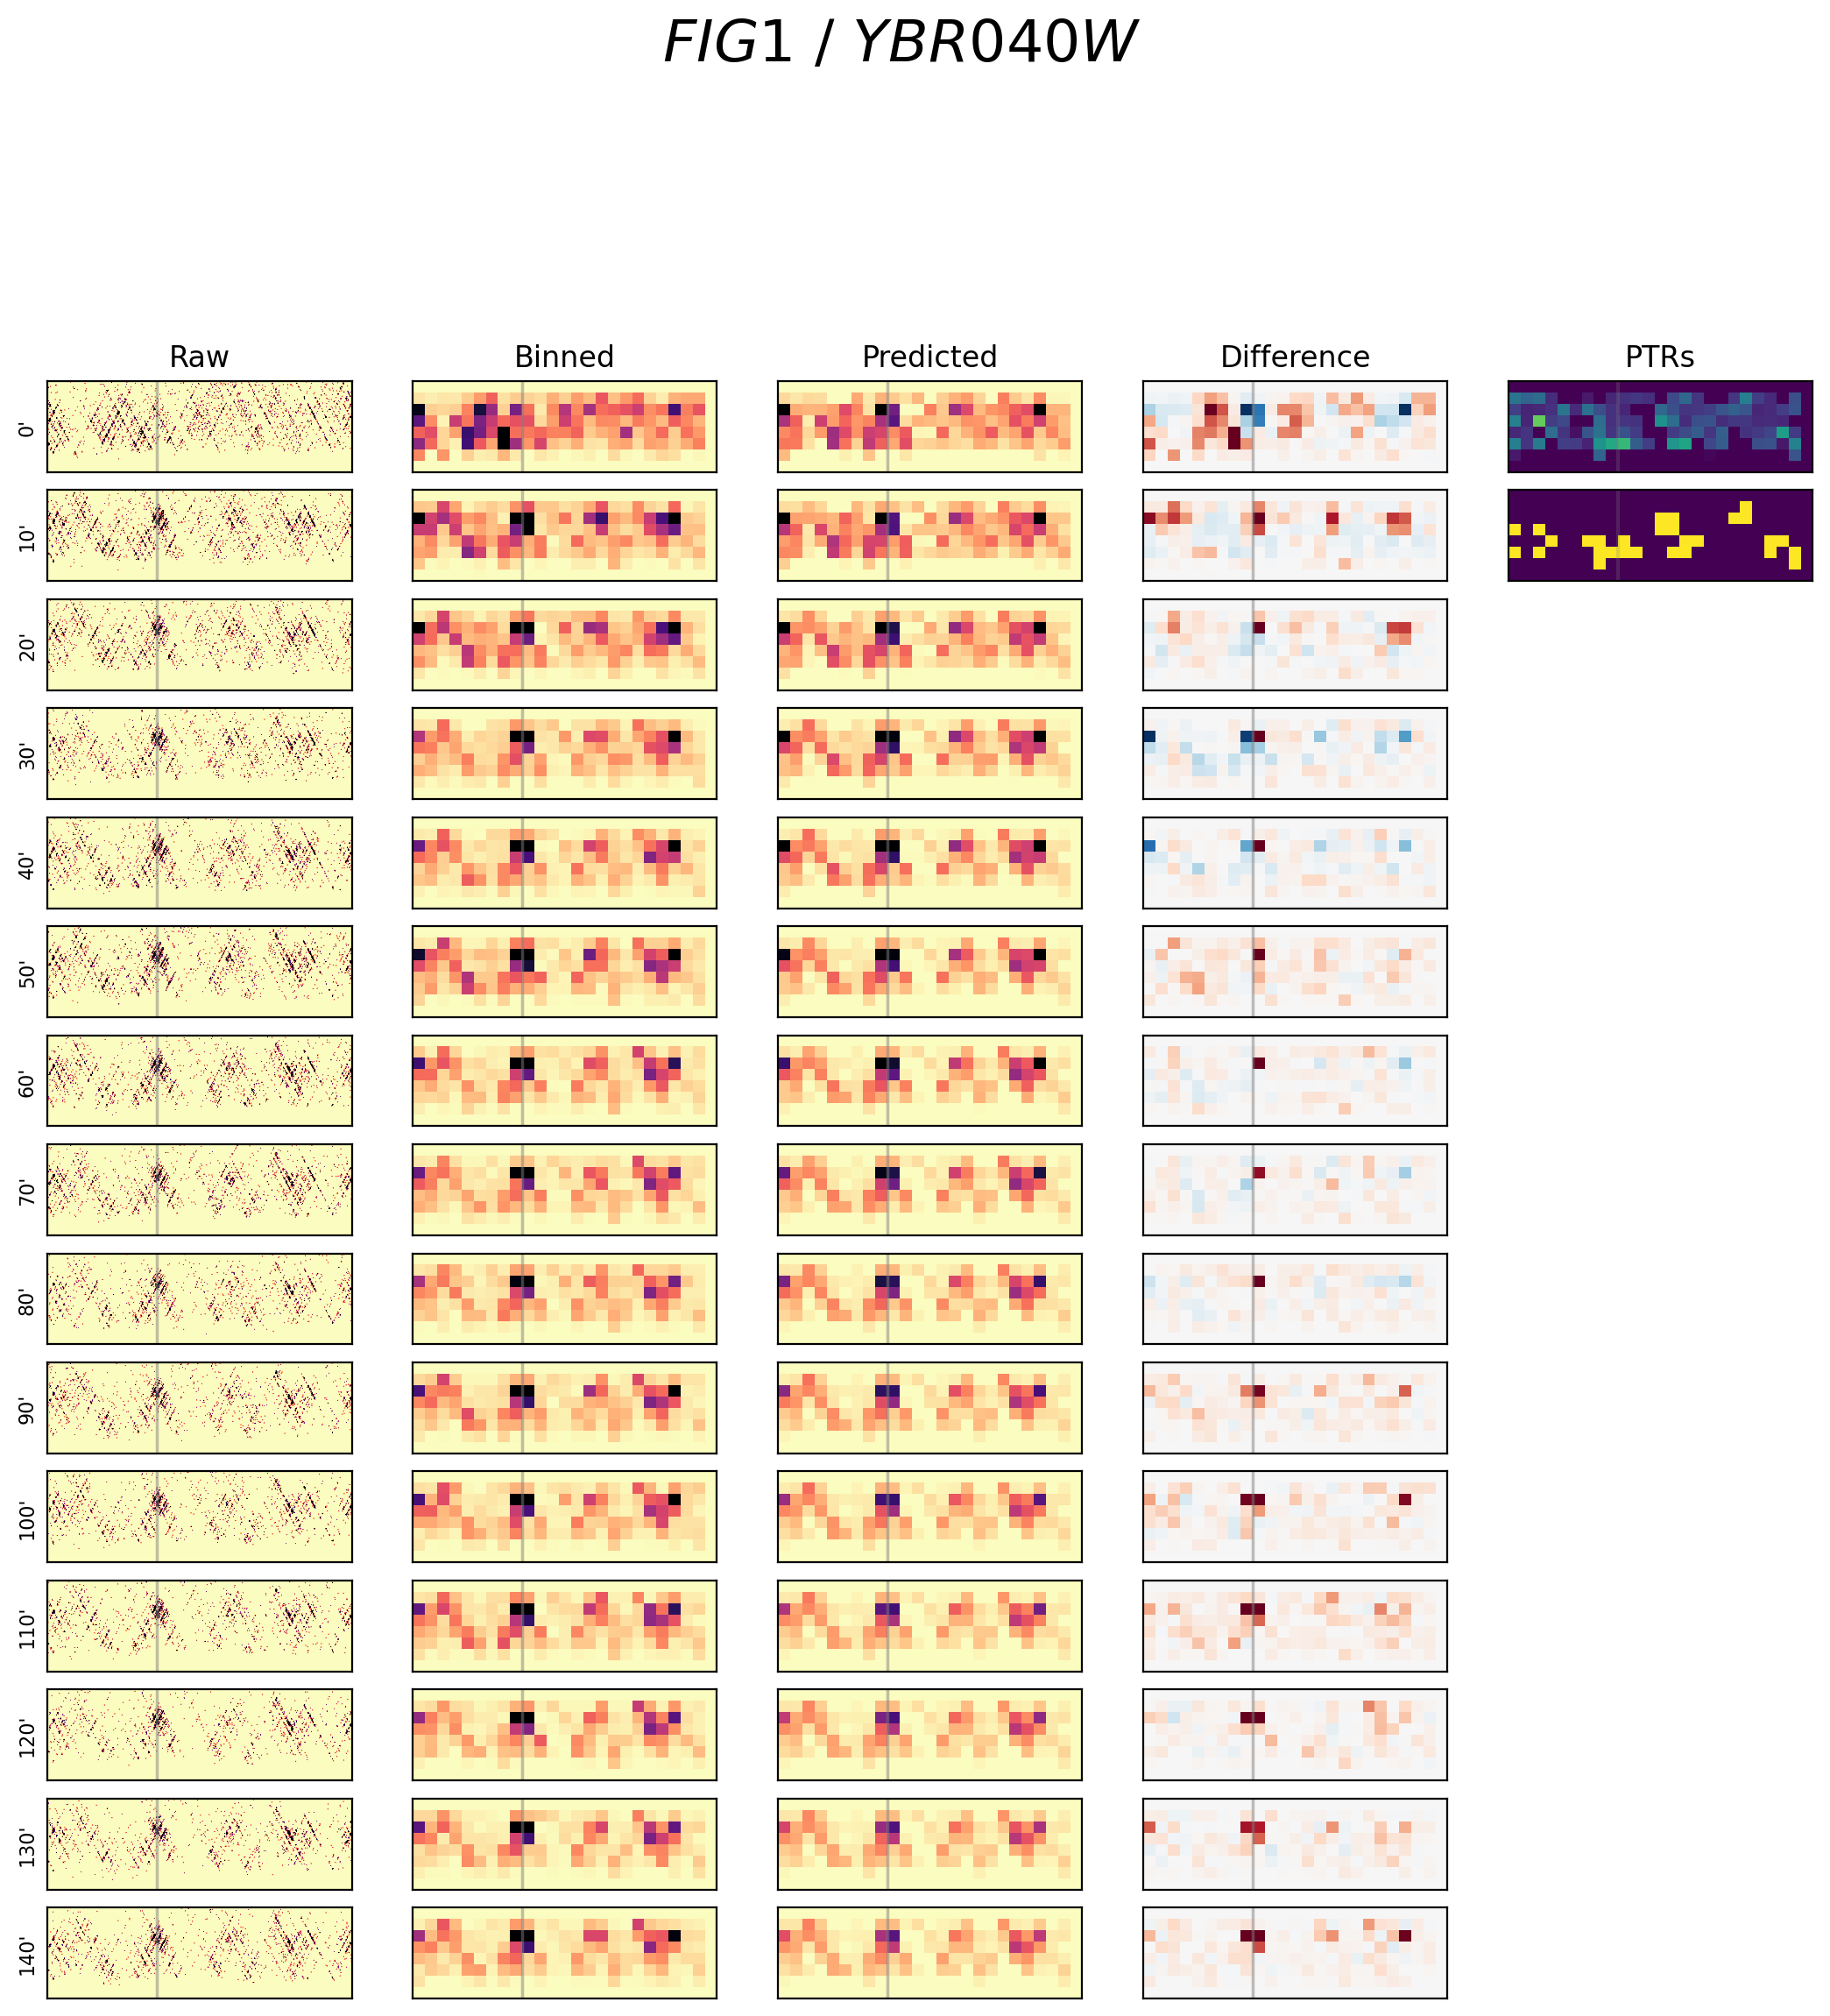

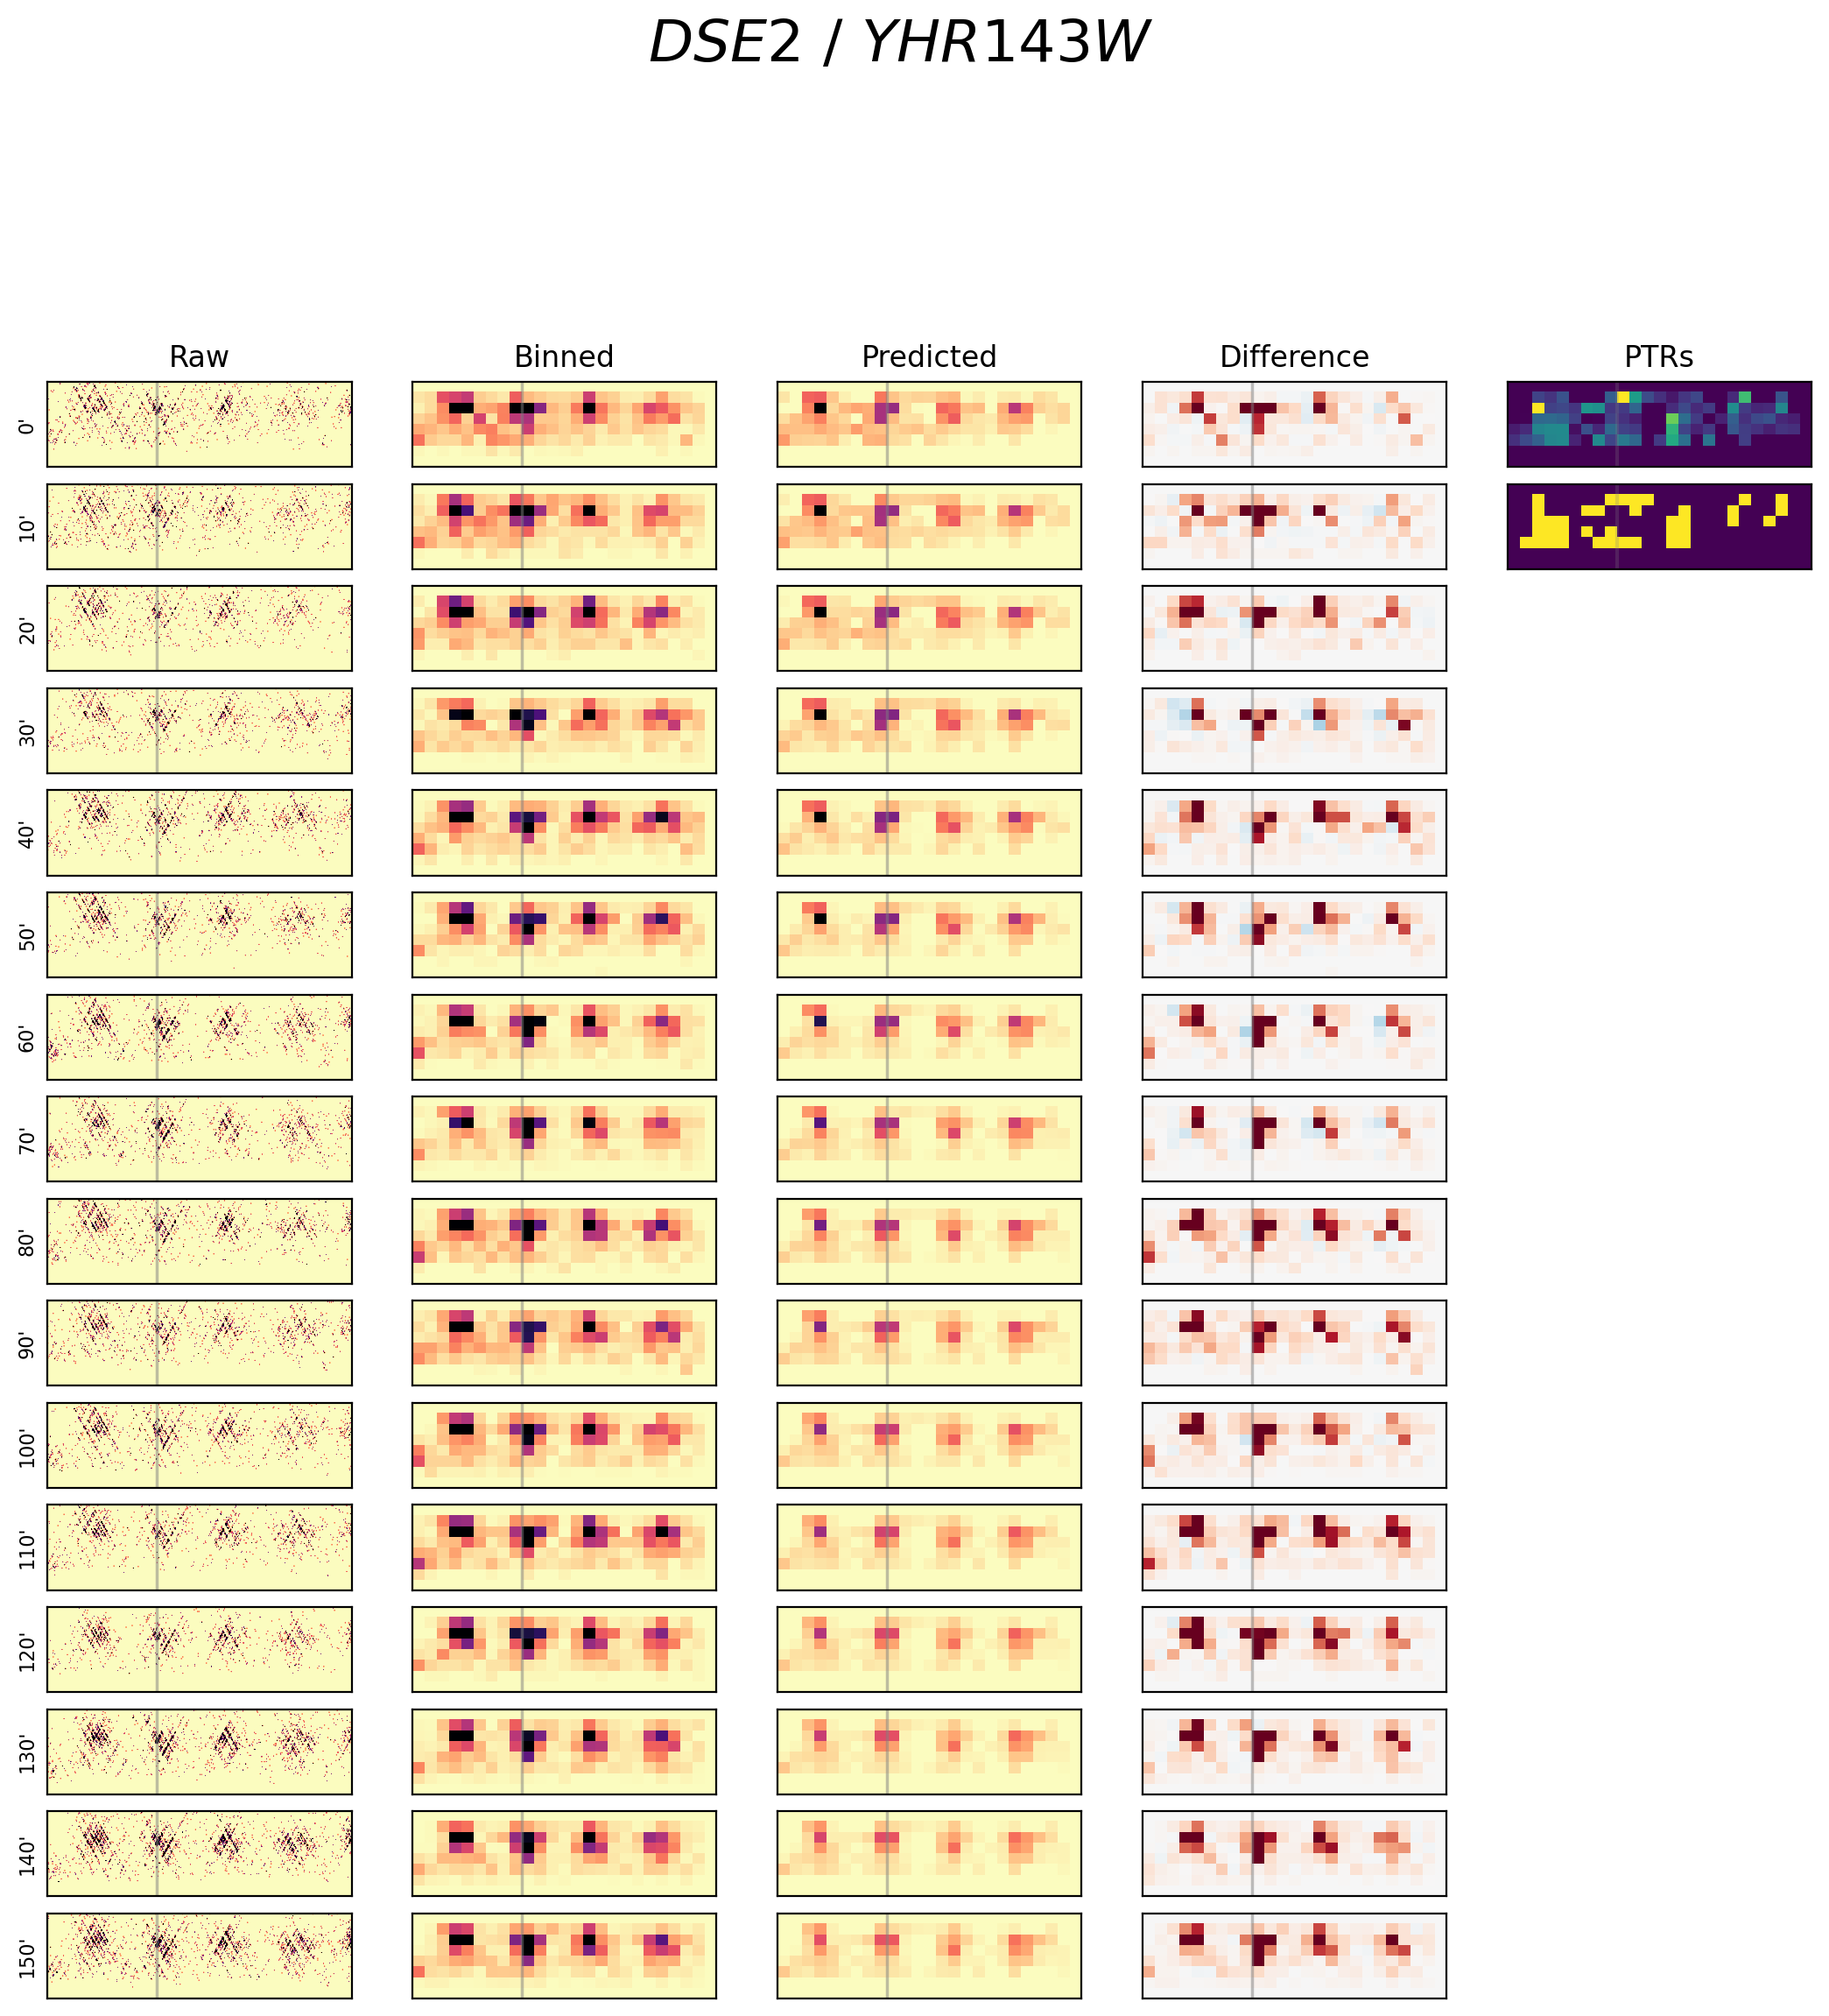

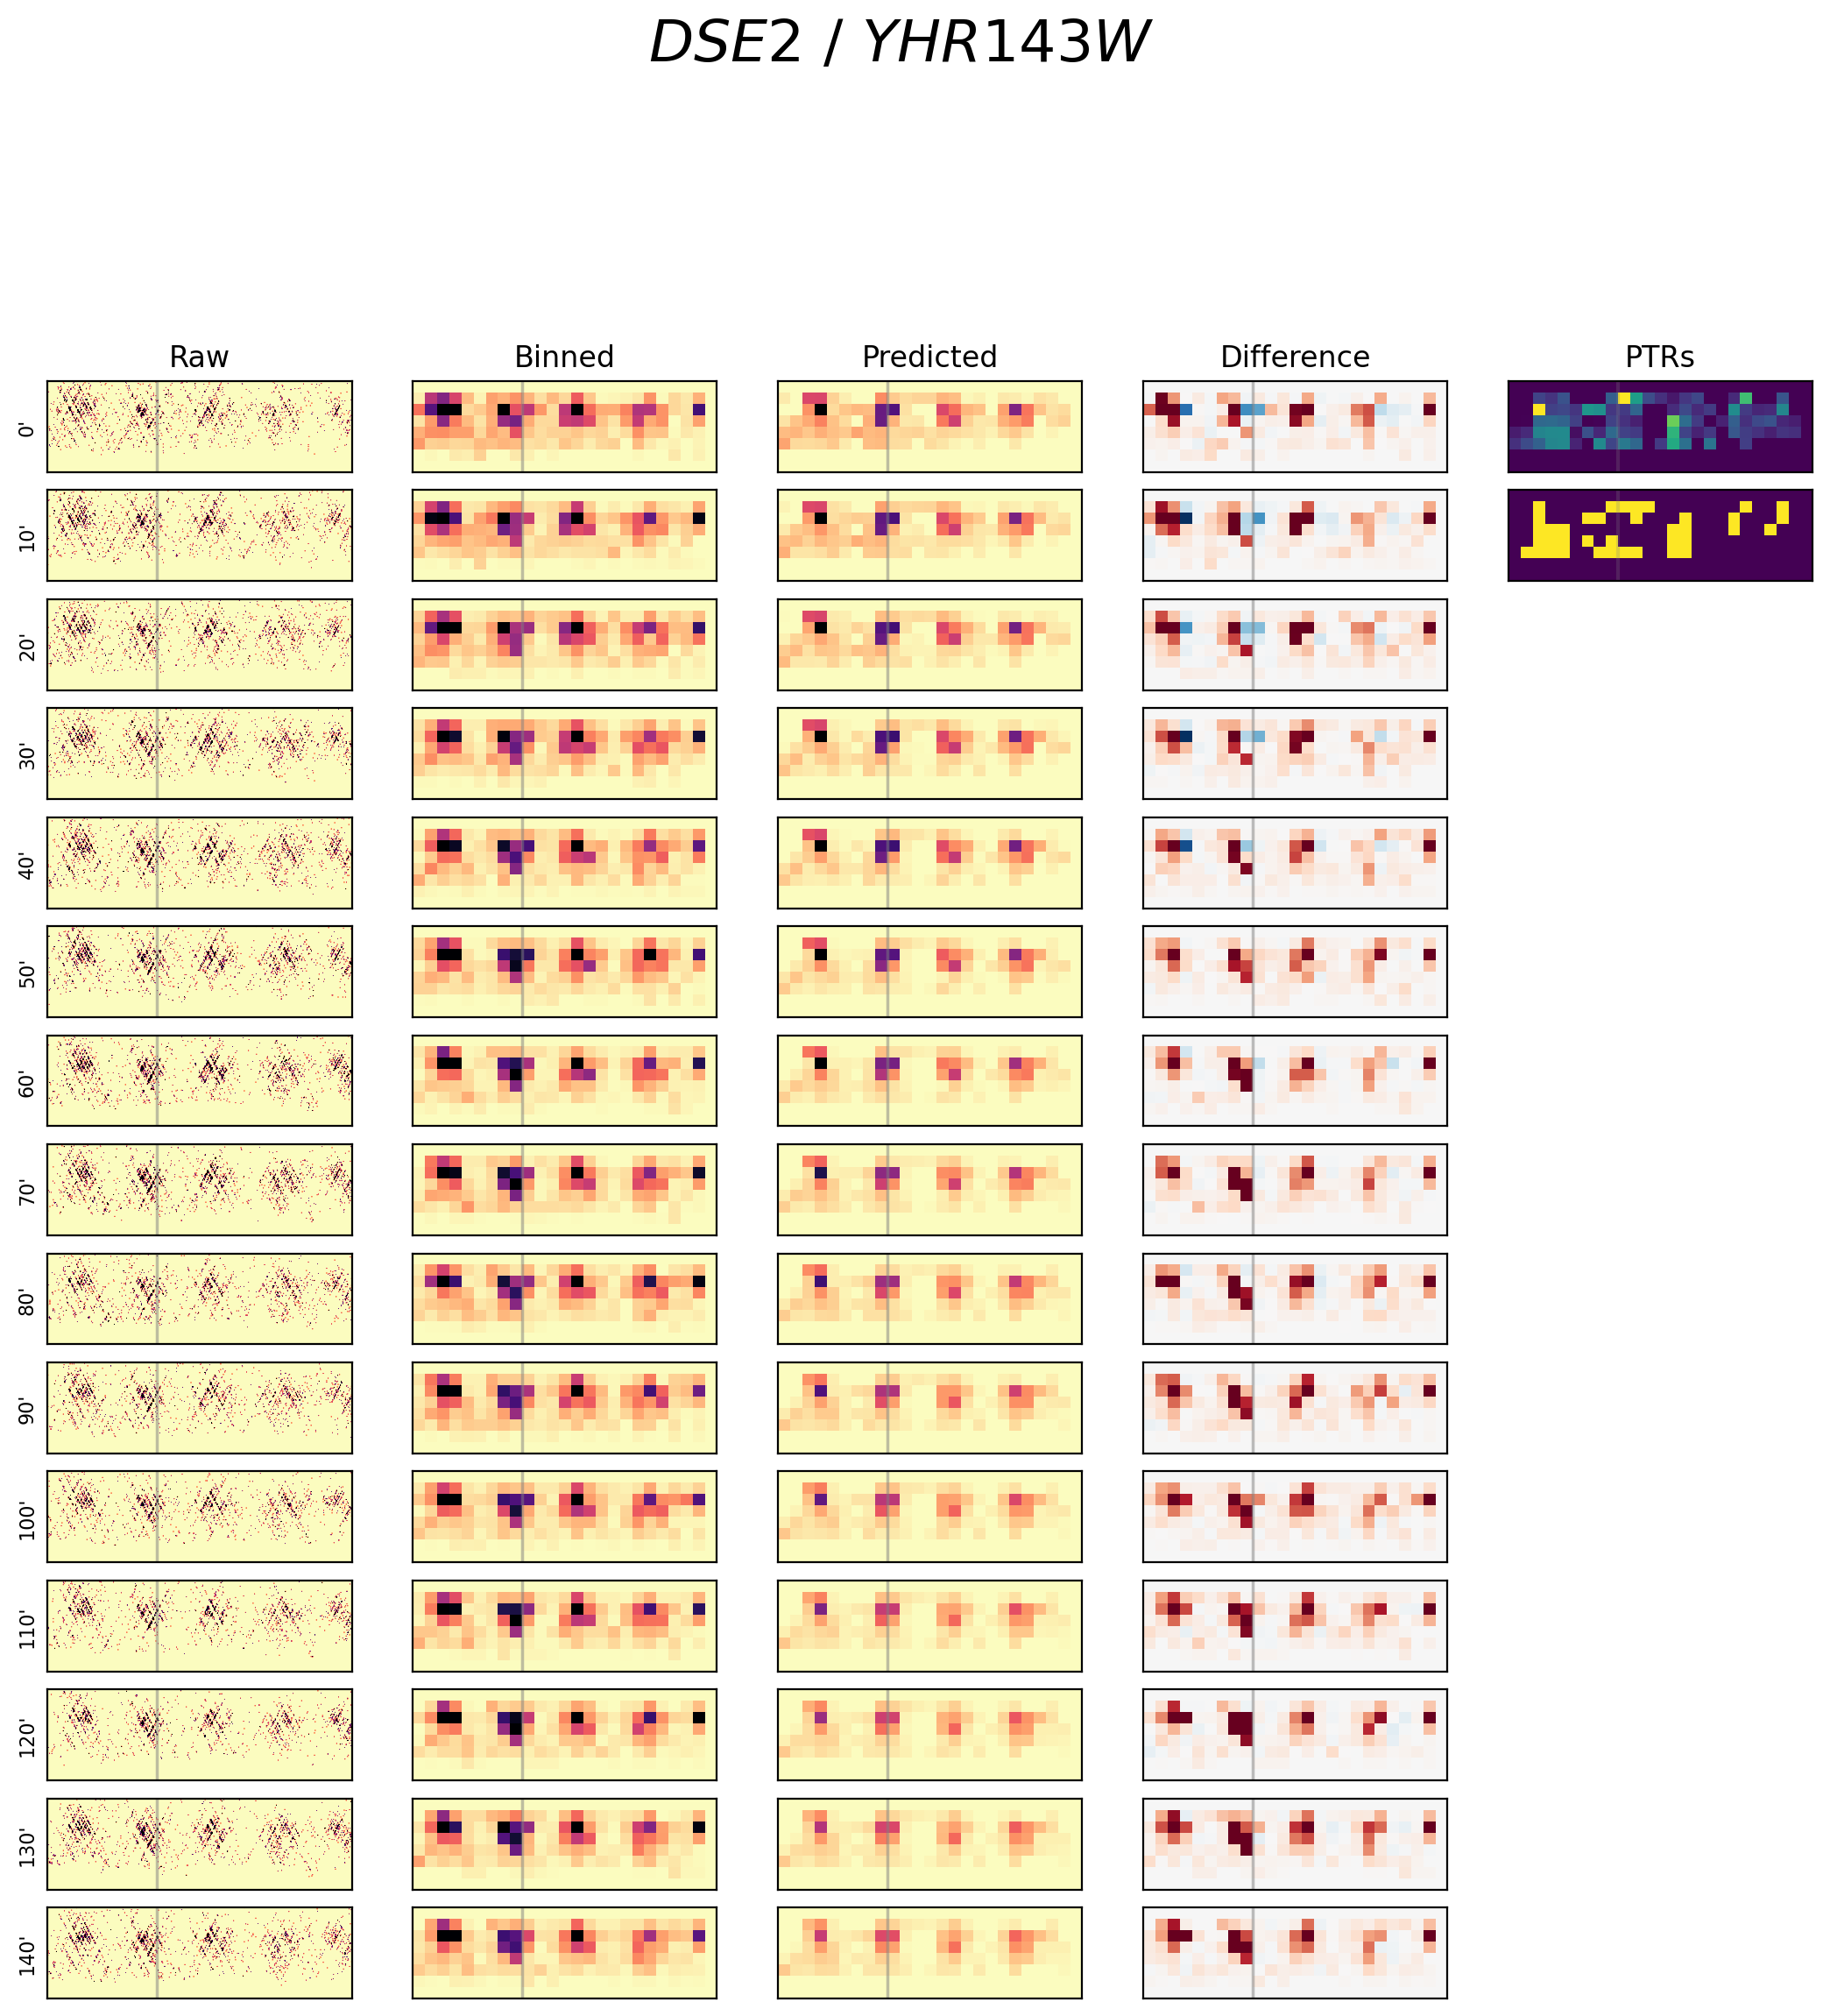

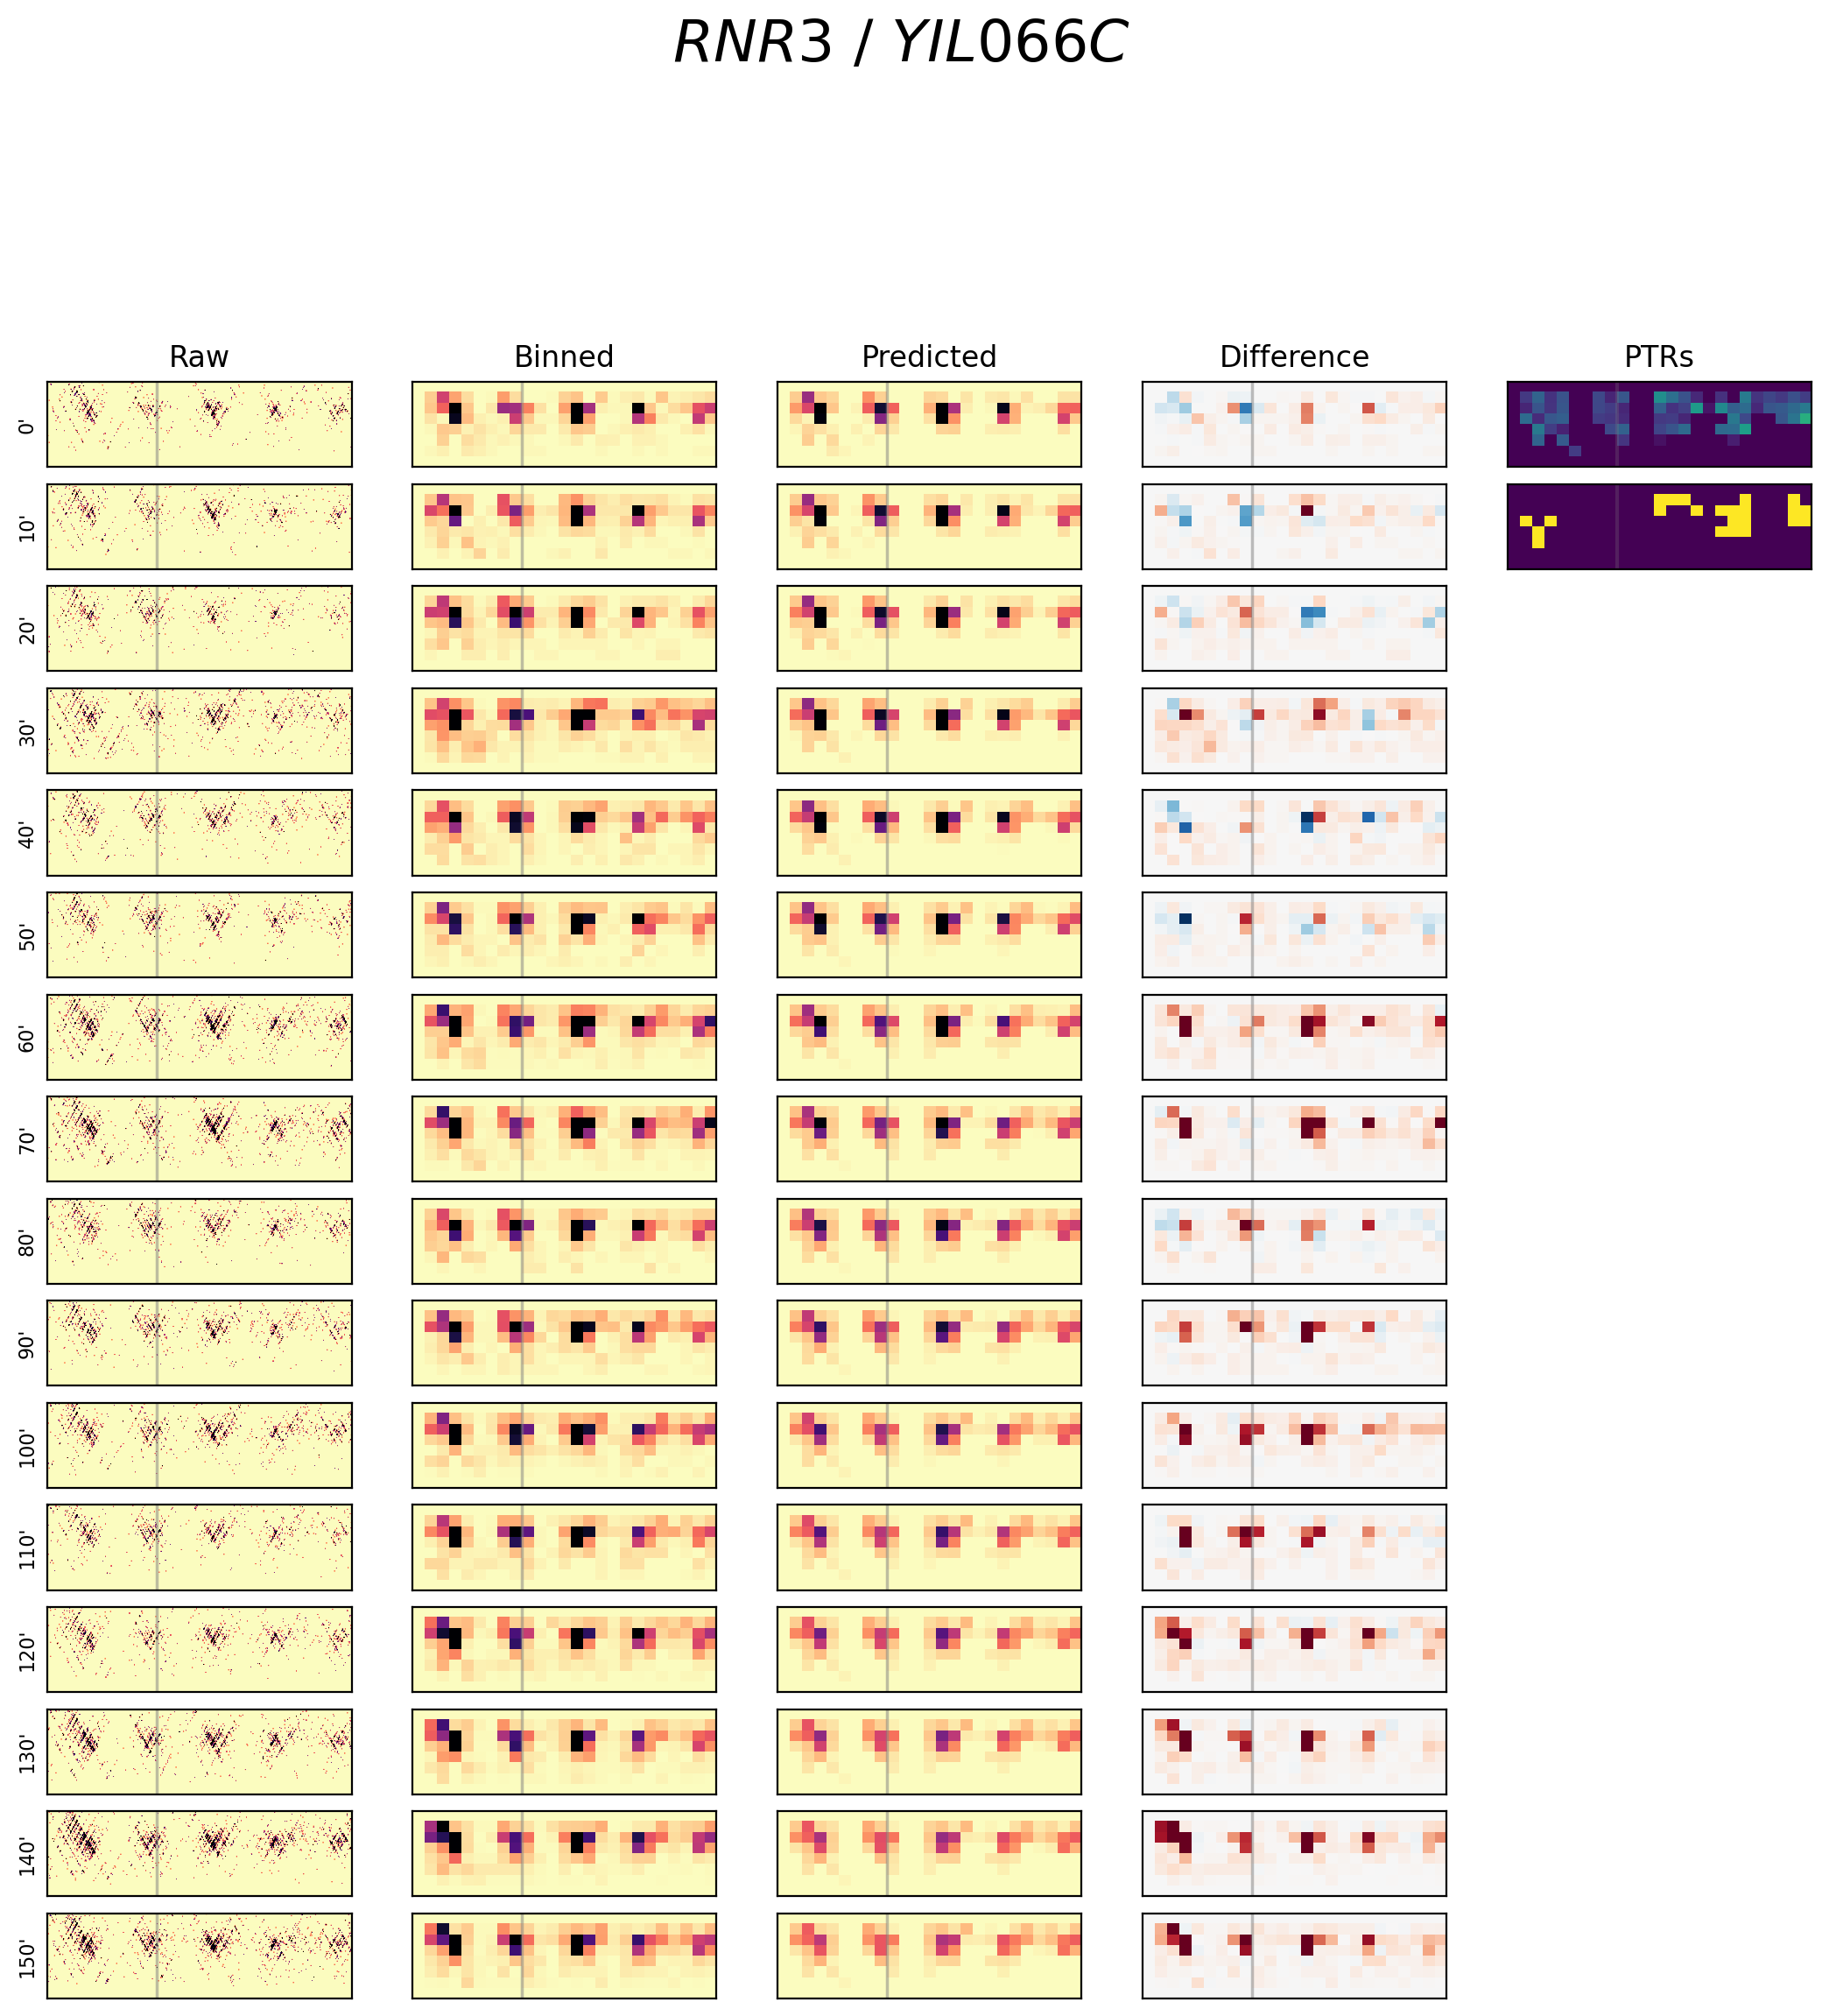

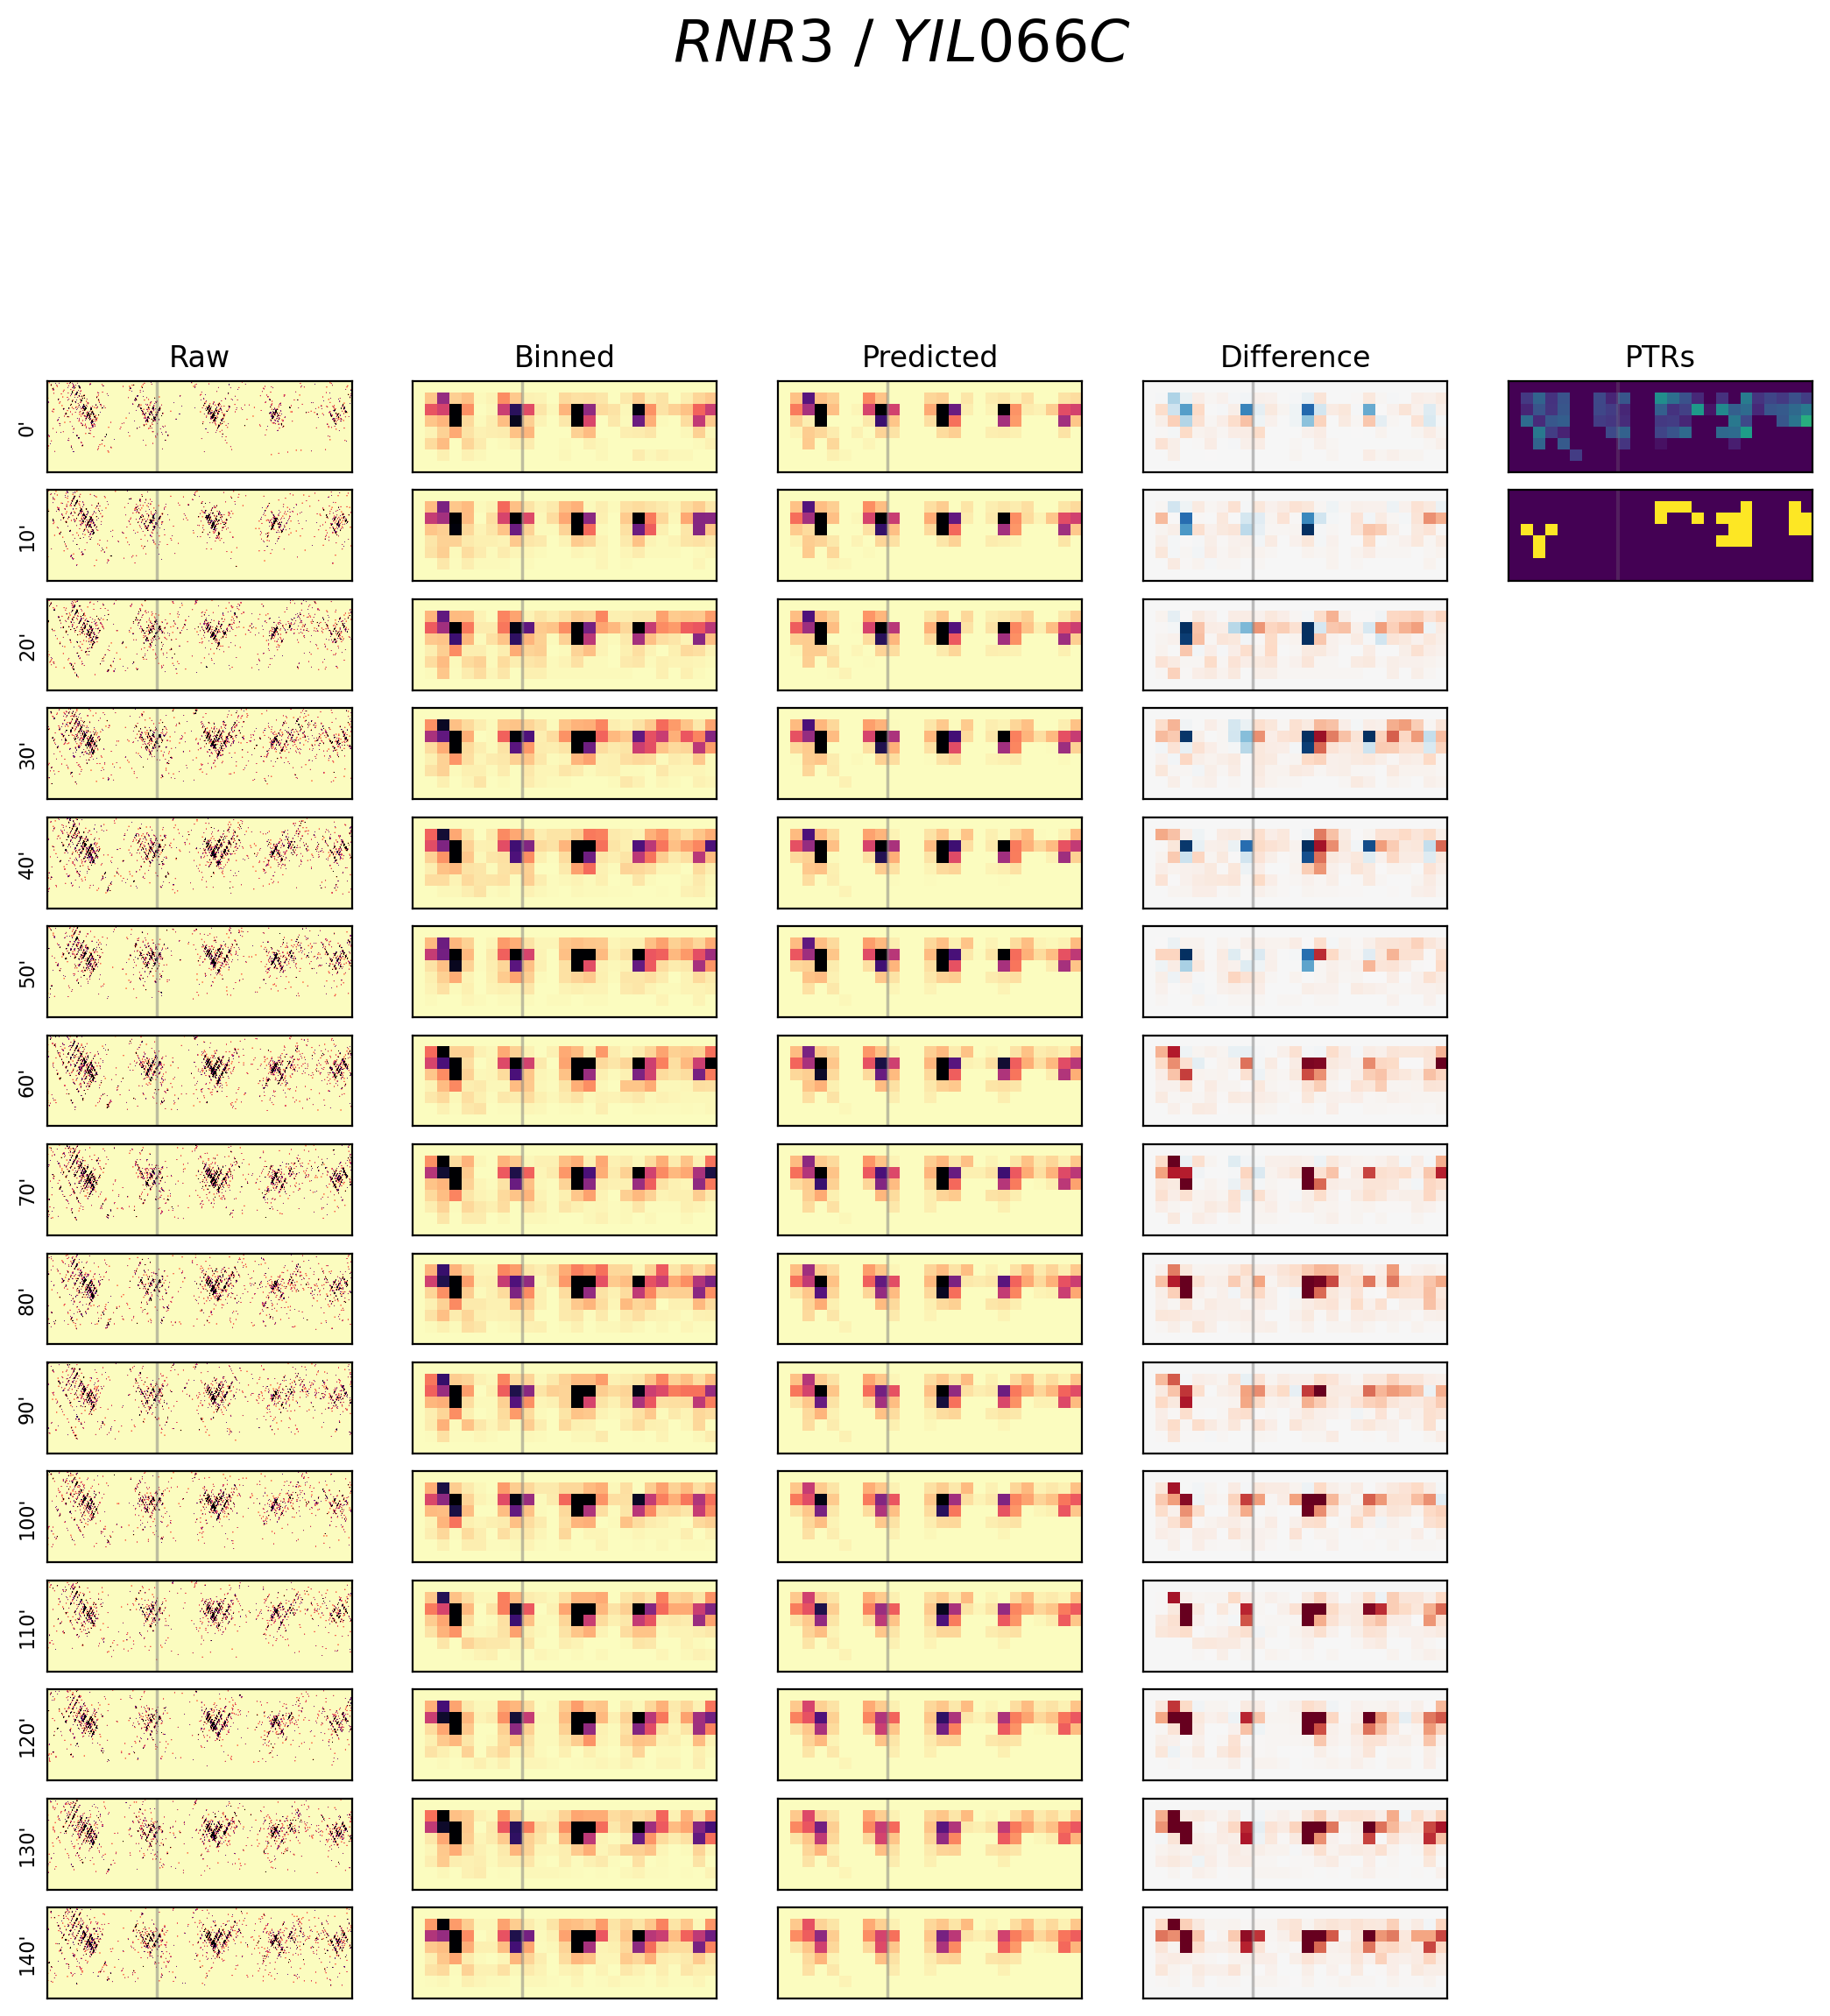

In [38]:
outdir = 'output/deconvolution_results_006_2024-03-07'

for gene_name in ['CLB2', 'SSK22', 'FIG1', 'DSE2', "RNR3"]:
    combined_model, combined_ge_config = deconvolve_combined(gene_name, outdir)

In [ ]:
combined_model, combined_ge_config = deconvolve_combined("CLB2", outdir)

Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.
Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.
Deconvolving combined model with gamma=0.006, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 200)
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 07 06:16:26 PM: Your problem has 45400 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 07 06:16:26 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 06:16:26 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 06:16:26 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation         